# Boca Juniors — Copa Libertadores 2023

## 1. Pregunta central y objetivo

**¿Cómo llegó Boca Juniors a la final de la Copa Libertadores 2023 sin ganar ningún partido de eliminación directa en los 90 minutos?**

El objetivo del notebook es reconstruir el recorrido de Boca a partir de datos de partidos, jugadores, alineaciones y contexto, para identificar qué cambió entre la fase de grupos y el mata-mata, qué patrones se repitieron y qué factores individuales resultaron decisivos.


## 2. Recolección y preparación de datos


### 2.1 Configuración, librerías y fuentes


In [18]:
import sys
print(sys.version)
print(sys.executable)

3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
C:\Users\emanu\AppData\Local\Programs\Python\Python313\python.exe


In [ ]:
%pip install pandas matplotlib mplsoccer LanusStats lxml requests scipy


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import LanusStats as ls

from io import StringIO
from mplsoccer import Pitch, VerticalPitch
from scipy.stats import binom

# Paleta utilizada en las visualizaciones
azul_fuerte = '#0057B8'
azul_claro = '#7FA9D8'
amarillo = '#F4C430'


In [ ]:
sofascore = ls.SofaScore()
fotmob = ls.FotMob()

libertadores_2023 = sofascore.scrape_league_stats(
    "Copa Libertadores",
    "2023"
)

boca_2023 = libertadores_2023[
    libertadores_2023['team'] == 'Boca Juniors'
].copy()


### 2.2 Funciones auxiliares


In [34]:
def separar_valor_porcentaje(valor):
    if isinstance(valor, str) and '(' in valor:
        cantidad = int(valor.split(' ')[0])
        porcentaje = int(
            valor.split('(')[1]
                 .replace('%)', '')
        )
        return cantidad, porcentaje
    
    return valor, None

In [35]:
def agregar_goles(df_partido, match_id):

    detalle = fotmob.request_match_details(match_id).json()

    goles_local = detalle['header']['teams'][0]['score']
    goles_visitante = detalle['header']['teams'][1]['score']

    df_partido = df_partido.copy()

    df_partido['goles'] = [
        goles_local,
        goles_visitante
    ]

    df_partido['goles_rival'] = [
        goles_visitante,
        goles_local
    ]

    return df_partido

In [42]:
def obtener_stat(df, key, equipo):
    fila = df[df['key'] == key]
    return fila.iloc[0][equipo]

In [36]:
def armar_partido(df_stats, fase, nombre_partido, local, visitante, match_id):

    def armar_fila(lado, equipo, rival, localia):

        # Variables que vienen como "cantidad (porcentaje%)"
        pases_acertados, precision_pases = separar_valor_porcentaje(
            obtener_stat(df_stats, 'accurate_passes', lado)
        )

        duelos_suelo, pct_duelos_suelo = separar_valor_porcentaje(
            obtener_stat(df_stats, 'ground_duels_won', lado)
        )

        duelos_aereos, pct_duelos_aereos = separar_valor_porcentaje(
            obtener_stat(df_stats, 'aerials_won', lado)
        )

        regates, pct_regates = separar_valor_porcentaje(
            obtener_stat(df_stats, 'dribbles_succeeded', lado)
        )

        largos, pct_largos = separar_valor_porcentaje(
            obtener_stat(df_stats, 'long_balls_accurate', lado)
        )

        centros, pct_centros = separar_valor_porcentaje(
            obtener_stat(df_stats, 'accurate_crosses', lado)
        )

        return {
            'fase': fase,
            'partido': nombre_partido,
            'equipo': equipo,
            'rival': rival,
            'localia': localia,

            # Posesión
            'posesion': obtener_stat(df_stats, 'BallPossesion', lado),

            # xG
            'xG': float(obtener_stat(df_stats, 'expected_goals', lado)),
            'xG_jugada': float(
                obtener_stat(df_stats, 'expected_goals_open_play', lado)
            ),
            'xG_pelota_parada': float(
                obtener_stat(df_stats, 'expected_goals_set_play', lado)
            ),
            'xG_sin_penal': float(
                obtener_stat(df_stats, 'expected_goals_non_penalty', lado)
            ),
            'xGOT': float(
                obtener_stat(df_stats, 'expected_goals_on_target', lado)
            ),

            # Remates
            'remates': obtener_stat(df_stats, 'total_shots', lado),
            'remates_arco': obtener_stat(df_stats, 'ShotsOnTarget', lado),
            'remates_fuera': obtener_stat(df_stats, 'ShotsOffTarget', lado),
            'remates_bloqueados': obtener_stat(
                df_stats, 'blocked_shots', lado
            ),
            'remates_area': obtener_stat(
                df_stats, 'shots_inside_box', lado
            ),
            'remates_fuera_area': obtener_stat(
                df_stats, 'shots_outside_box', lado
            ),
            'grandes_ocasiones': obtener_stat(
                df_stats, 'big_chance', lado
            ),
            'grandes_ocasiones_falladas': obtener_stat(
                df_stats, 'big_chance_missed_title', lado
            ),

            # Pases
            'pases': obtener_stat(df_stats, 'passes', lado),
            'pases_acertados': pases_acertados,
            'precision_pases': precision_pases,
            'pases_campo_propio': obtener_stat(
                df_stats, 'own_half_passes', lado
            ),
            'pases_campo_rival': obtener_stat(
                df_stats, 'opposition_half_passes', lado
            ),
            'largos_acertados': largos,
            'precision_largos': pct_largos,
            'centros_acertados': centros,
            'precision_centros': pct_centros,

            # Duelos / regates
            'duelos_ganados': obtener_stat(
                df_stats, 'duel_won', lado
            ),
            'duelos_suelo_ganados': duelos_suelo,
            'pct_duelos_suelo': pct_duelos_suelo,
            'duelos_aereos_ganados': duelos_aereos,
            'pct_duelos_aereos': pct_duelos_aereos,
            'regates_exitosos': regates,
            'pct_regates': pct_regates,

            # Defensa
            'tackles': obtener_stat(
                df_stats, 'matchstats.headers.tackles', lado
            ),
            'intercepciones': obtener_stat(
                df_stats, 'interceptions', lado
            ),
            'bloqueos': obtener_stat(
                df_stats, 'shot_blocks', lado
            ),
            'despejes': obtener_stat(
                df_stats, 'clearances', lado
            ),
            'atajadas': obtener_stat(
                df_stats, 'keeper_saves', lado
            ),

            # Otros
            'faltas': obtener_stat(df_stats, 'fouls', lado),
            'corners': obtener_stat(df_stats, 'corners', lado),
            'offsides': obtener_stat(df_stats, 'Offsides', lado),
            'amarillas': obtener_stat(
                df_stats, 'yellow_cards', lado
            ),
            'rojas': obtener_stat(
                df_stats, 'red_cards', lado
            )
        }

    df_partido = pd.DataFrame([
        armar_fila('home', local, visitante, 'Local'),
        armar_fila('away', visitante, local, 'Visitante')
    ])

    df_partido = agregar_goles(
        df_partido,
        match_id
    )

    return df_partido

In [37]:
def armar_alineacion(lineup, fase, nombre_partido, lado_boca):

    jugadores = []

    formacion = lineup[lado_boca]['formation']

    for jugador in lineup[lado_boca]['players']:

        if jugador['substitute'] == False:

            posicion_natural = jugador['player']['position']
            posicion_partido = jugador['position']

            jugadores.append({
                'fase': fase,
                'partido': nombre_partido,
                'formacion': formacion,
                'jugador': jugador['player']['name'],
                'posicion_natural': posicion_natural,
                'posicion_partido': posicion_partido,
                'cambio_posicion': posicion_natural != posicion_partido
            })

    return pd.DataFrame(jugadores)

In [38]:
def armar_stats_jugadores(lineup, fase, partido, lado_boca):

    filas = []

    for jugador in lineup[lado_boca]['players']:

        stats = jugador.get('statistics', {})
        minutos = stats.get('minutesPlayed', 0)

        # Solo jugadores que efectivamente jugaron
        if minutos > 0:

            filas.append({
                'fase': fase,
                'partido': partido,
                'jugador': jugador['player']['name'],
                'titular': not jugador['substitute'],
                'posicion': jugador['position'],
                'minutos': minutos,

                # Rendimiento
                'rating': stats.get('rating', None),

                # Ataque
                'goles': stats.get('goals', 0),
                'asistencias': stats.get('goalAssist', 0),
                'xG': stats.get('expectedGoals', 0),
                'xA': stats.get('expectedAssists', 0),
                'remates': stats.get('totalShots', 0),
                'remates_arco': stats.get('onTargetScoringAttempt', 0),
                'pases_clave': stats.get('keyPass', 0),

                # Pases
                'pases': stats.get('totalPass', 0),
                'pases_acertados': stats.get('accuratePass', 0),

                # Duelos / regates
                'duelos_ganados': stats.get('duelWon', 0),
                'regates_intentados': stats.get('totalContest', 0),
                'regates_exitosos': stats.get('wonContest', 0),

                # Defensa
                'tackles': stats.get('totalTackle', 0),
                'intercepciones': stats.get('interceptionWon', 0),
                'recuperaciones': stats.get('ballRecovery', 0),
                'despejes': stats.get('totalClearance', 0),

                # Pérdidas
                'perdidas': stats.get('possessionLostCtrl', 0),

                # Arqueros
                'atajadas': stats.get('saves', 0),
                'goles_evitados': stats.get('goalsPrevented', 0)
            })

    return pd.DataFrame(filas)

In [246]:
def resumir_penales(df):

    total = len(df)

    atajados = (df['resolucion'] == 'Atajado').sum()
    convertidos = (df['resolucion'] == 'Convertido').sum()
    desviados = (df['resolucion'] == 'Desviado').sum()

    return {
        'total': total,
        'atajados': atajados,
        'convertidos': convertidos,
        'desviados': desviados,
        'pct_atajados': (atajados / total) * 100,
        'pct_no_convertidos': ((atajados + desviados) / total) * 100,
        'pct_atajados_al_arco': (
            atajados / (atajados + convertidos)
        ) * 100
    }

In [274]:
def comparar_serie(df, nombre_serie):

    boca = df[df['equipo'] == 'Boca Juniors']
    rival = df[df['equipo'] != 'Boca Juniors']

    return {
        'serie': nombre_serie,

        'goles_boca': boca['goles'].sum(),
        'goles_rival': rival['goles'].sum(),

        'xG_boca': boca['xG'].sum(),
        'xG_rival': rival['xG'].sum(),

        'remates_boca': boca['remates'].sum(),
        'remates_rival': rival['remates'].sum(),

        'remates_arco_boca': boca['remates_arco'].sum(),
        'remates_arco_rival': rival['remates_arco'].sum(),

        'grandes_ocasiones_boca': boca['grandes_ocasiones'].sum(),
        'grandes_ocasiones_rival': rival['grandes_ocasiones'].sum(),

        'posesion_boca': boca['posesion'].mean(),
        'posesion_rival': rival['posesion'].mean(),

        'despejes_boca': boca['despejes'].sum(),
        'despejes_rival': rival['despejes'].sum()
    }

In [287]:
def contar_superioridad(df):

    return pd.Series({
        'más posesión': (
            df['posesion_boca'] > df['posesion_rival']
        ).sum(),

        'más xG': (
            df['xG_boca'] > df['xG_rival']
        ).sum(),

        'más remates': (
            df['remates_boca'] > df['remates_rival']
        ).sum(),

        'más remates al arco': (
            df['remates_arco_boca'] > df['remates_arco_rival']
        ).sum(),

        'más grandes ocasiones': (
            df['grandes_ocasiones_boca'] >
            df['grandes_ocasiones_rival']
        ).sum()
    })

In [326]:
def armar_df_periodo(detalle, periodo):

    filas = []

    bloques = detalle['content']['stats']['Periods'][periodo]['stats']

    for bloque in bloques:
        for stat in bloque['stats']:

            if stat['stats'] != [None, None]:

                filas.append({
                    'key': stat['key'],
                    'Boca': stat['stats'][0],
                    'Fluminense': stat['stats'][1]
                })

    return (
        pd.DataFrame(filas)
        .drop_duplicates(subset='key')
        .reset_index(drop=True)
    )

In [329]:
def sumar_stat_90(key, lado):

    valor_1t = obtener_stat(
        final_primer_tiempo,
        key,
        lado
    )

    valor_2t = obtener_stat(
        final_segundo_tiempo,
        key,
        lado
    )

    return float(valor_1t) + float(valor_2t)

In [330]:
def posesion_90(lado):

    return (
        obtener_stat(
            final_primer_tiempo,
            'BallPossesion',
            lado
        )
        +
        obtener_stat(
            final_segundo_tiempo,
            'BallPossesion',
            lado
        )
    ) / 2

In [335]:
def posesion_extra(lado):

    return (
        obtener_stat(
            final_primer_extra,
            'BallPossesion',
            lado
        )
        +
        obtener_stat(
            final_segundo_extra,
            'BallPossesion',
            lado
        )
    ) / 2

In [334]:
def sumar_stat_extra(key, lado):

    valor_1 = obtener_stat(
        final_primer_extra,
        key,
        lado
    )

    valor_2 = obtener_stat(
        final_segundo_extra,
        key,
        lado
    )

    return float(valor_1) + float(valor_2)

In [366]:
def obtener_posiciones_formacion(formacion):

    lineas = [int(x) for x in formacion.split('-')]

    posiciones = []

    # Arquero
    posiciones.append((8, 50))

    # Altura de cada línea
    alturas = np.linspace(25, 80, len(lineas))

    for cantidad, altura in zip(lineas, alturas):

        if cantidad == 1:
            posiciones_y = [50]

        elif cantidad == 2:
            posiciones_y = [38, 62]

        elif cantidad == 3:
            posiciones_y = [25, 50, 75]

        elif cantidad == 4:
            posiciones_y = [15, 38, 62, 85]

        elif cantidad == 5:
            posiciones_y = [10, 30, 50, 70, 90]

        for y in posiciones_y:
            posiciones.append(
                (altura, y)
            )

    return posiciones

In [361]:
def graficar_formacion(formacion, partidos):

    pitch = VerticalPitch(
        pitch_type='opta'
    )

    fig, ax = pitch.draw(
        figsize=(6, 8)
    )

    posiciones = obtener_posiciones_formacion(
        formacion
    )

    x = [pos[0] for pos in posiciones]
    y = [pos[1] for pos in posiciones]

    pitch.scatter(
        x,
        y,
        s=600,
        color=azul_fuerte,
        edgecolors='white',
        linewidth=2,
        ax=ax
    )

    ax.set_title(
        f'{formacion} - {partidos} partido(s)',
        fontsize=14
    )

    plt.show()

### 2.3 Datos de partidos — FotMob


#### Fase de grupos


In [ ]:
id_monagas_boca = 4147344 #fecha 1

stats_monagas_boca = fotmob.get_general_match_stats(
    id_monagas_boca
)

partido_monagas_boca = armar_partido(
    stats_monagas_boca,
    'Grupos',
    'Monagas vs Boca',
    'Monagas',
    'Boca Juniors',
    id_monagas_boca
)


In [ ]:
id_boca_pereira = 4147668 #fecha 2
stats_boca_pereira = fotmob.get_general_match_stats(
    id_boca_pereira
)
partido_boca_pereira = armar_partido(
    stats_boca_pereira,
    'Grupos',
    'Boca vs Deportivo Pereira',
    'Boca Juniors',
    'Deportivo Pereira',
    id_boca_pereira
)


In [ ]:
id_colo_colo_boca = 4147669 # fecha 3
stats_colo_colo_boca = fotmob.get_general_match_stats(
    id_colo_colo_boca
)
partido_colo_colo_boca = armar_partido(
    stats_colo_colo_boca,
    'Grupos',
    'Colo-Colo vs Boca',
    'Colo-Colo',
    'Boca Juniors',
    id_colo_colo_boca
)


In [ ]:
id_pereira_boca = 4147623 #fecha 4
stats_pereira_boca = fotmob.get_general_match_stats(
    id_pereira_boca
)
partido_pereira_boca = armar_partido(
    stats_pereira_boca,
    'Grupos',
    'Deportivo Pereira vs Boca',
    'Deportivo Pereira',
    'Boca Juniors',
    id_pereira_boca
)


In [ ]:
id_boca_colo_colo = 4147624 ## fecha 5
stats_boca_colo_colo = fotmob.get_general_match_stats(
    id_boca_colo_colo
)
partido_boca_colo_colo = armar_partido(
    stats_boca_colo_colo,
    'Grupos',
    'Boca vs Colo-Colo',
    'Boca Juniors',
    'Colo-Colo',
    id_boca_colo_colo
)


In [ ]:
id_boca_monagas = 4147626 ##fecha 6, ultima
stats_boca_monagas = fotmob.get_general_match_stats(
    id_boca_monagas
)
partido_boca_monagas = armar_partido(
    stats_boca_monagas,
    'Grupos',
    'Boca vs Monagas',
    'Boca Juniors',
    'Monagas',
    id_boca_monagas
)


#### Mata-mata y final


In [ ]:
id_nacional_boca_ida = 4233142 ### primer partido lo movi despues de definir funcion

stats_nacional_boca_ida = fotmob.get_general_match_stats(
    id_nacional_boca_ida
)

partido_nacional_boca = armar_partido(
    stats_nacional_boca_ida,
    'Octavos',
    'Nacional vs Boca',
    'Nacional',
    'Boca Juniors',
    id_nacional_boca_ida
)


In [ ]:
id_boca_nacional_vuelta = 4233156 ###vuelta bombonera
stats_boca_nacional_vuelta = fotmob.get_general_match_stats( ###repetimos lo de la ida
    id_boca_nacional_vuelta
)
partido_boca_nacional = armar_partido(
    stats_boca_nacional_vuelta,
    'Octavos',
    'Boca vs Nacional',
    'Boca Juniors',
    'Nacional',
    id_boca_nacional_vuelta
)


In [ ]:
id_boca_racing_ida = 4295690
stats_boca_racing_ida = fotmob.get_general_match_stats(
    id_boca_racing_ida
)
partido_boca_racing = armar_partido(
    stats_boca_racing_ida,
    'Cuartos',
    'Boca vs Racing',
    'Boca Juniors',
    'Racing Club',
    id_boca_racing_ida
)


In [ ]:
id_racing_boca_vuelta = 4295691 ####partido de vuelta
stats_racing_boca_vuelta = fotmob.get_general_match_stats(
    id_racing_boca_vuelta
)
partido_racing_boca = armar_partido(
    stats_racing_boca_vuelta,
    'Cuartos',
    'Racing vs Boca',
    'Racing Club',
    'Boca Juniors',
    id_racing_boca_vuelta
)


In [ ]:
id_boca_palmeiras_ida = 4296413
stats_boca_palmeiras_ida = fotmob.get_general_match_stats(
    id_boca_palmeiras_ida
)
partido_boca_palmeiras = armar_partido(
    stats_boca_palmeiras_ida,
    'Semifinal',
    'Boca vs Palmeiras',
    'Boca Juniors',
    'Palmeiras',
    id_boca_palmeiras_ida
)


In [ ]:
id_palmeiras_boca_vuelta = 4296414 ### vuelta, expulsion de rojo
stats_palmeiras_boca_vuelta = fotmob.get_general_match_stats(
    id_palmeiras_boca_vuelta
)
partido_palmeiras_boca = armar_partido(
    stats_palmeiras_boca_vuelta,
    'Semifinal',
    'Palmeiras vs Boca',
    'Palmeiras',
    'Boca Juniors',
    id_palmeiras_boca_vuelta
)


In [ ]:
id_boca_fluminense_final = 4296417
stats_boca_fluminense_final = fotmob.get_general_match_stats(
    id_boca_fluminense_final
)
partido_boca_fluminense = armar_partido(
    stats_boca_fluminense_final,
    'Final',
    'Boca vs Fluminense',
    'Boca Juniors',
    'Fluminense',
    id_boca_fluminense_final
)


In [ ]:
partidos_boca_2023 = pd.concat([
    partido_monagas_boca,
    partido_boca_pereira,
    partido_colo_colo_boca,
    partido_pereira_boca,
    partido_boca_colo_colo,
    partido_boca_monagas,
    partido_nacional_boca,
    partido_boca_nacional,
    partido_boca_racing,
    partido_racing_boca,
    partido_boca_palmeiras,
    partido_palmeiras_boca,
    partido_boca_fluminense
], ignore_index=True)

print("Shape:", partidos_boca_2023.shape)
partidos_boca_2023[['fase', 'partido', 'equipo', 'goles', 'goles_rival']].head()


In [ ]:
partidos_boca_2023.to_csv(
    'partidos_boca_2023_completo.csv',
    index=False
)


### 2.4 Alineaciones y formaciones — SofaScore


En esta sección se analizan las formaciones utilizadas por Boca Juniors a lo largo de la Copa Libertadores 2023, tanto en fase de grupos como en mata-mata, y se visualizan los esquemas más empleados por Jorge Almirón.

#### Fase de grupos


In [152]:
# Monagas vs Boca
url_monagas_boca = 'https://www.sofascore.com/es-la/football/match/monagas-boca-juniors/cobsIzc#id:11173693'

lineup_monagas_boca = sofascore.get_lineups(
    url_monagas_boca
)

alineacion_monagas_boca = armar_alineacion(
    lineup_monagas_boca,
    'Grupos',
    'Monagas vs Boca',
    'away'
)

In [153]:
# Boca vs Deportivo Pereira
url_boca_pereira = 'https://www.sofascore.com/es-la/football/match/deportivo-pereira-boca-juniors/cobsjxc#id:11173670'

lineup_boca_pereira = sofascore.get_lineups(
    url_boca_pereira
)

alineacion_boca_pereira = armar_alineacion(
    lineup_boca_pereira,
    'Grupos',
    'Boca vs Deportivo Pereira',
    'home'
)

In [154]:
# Colo-Colo vs Boca
url_colo_colo_boca = 'https://www.sofascore.com/es-la/football/match/boca-juniors-colo-colo/fnbscob#id:11173719'

lineup_colo_colo_boca = sofascore.get_lineups(
    url_colo_colo_boca
)

alineacion_colo_colo_boca = armar_alineacion(
    lineup_colo_colo_boca,
    'Grupos',
    'Colo-Colo vs Boca',
    'away'
)

In [155]:
# Deportivo Pereira vs Boca
url_pereira_boca = 'https://www.sofascore.com/es-la/football/match/deportivo-pereira-boca-juniors/cobsjxc#id:11173718'

lineup_pereira_boca = sofascore.get_lineups(
    url_pereira_boca
)

alineacion_pereira_boca = armar_alineacion(
    lineup_pereira_boca,
    'Grupos',
    'Deportivo Pereira vs Boca',
    'away'
)

In [156]:
# Boca vs Colo-Colo
url_boca_colo_colo = 'https://www.sofascore.com/es-la/football/match/boca-juniors-colo-colo/fnbscob#id:11173722'

lineup_boca_colo_colo = sofascore.get_lineups(
    url_boca_colo_colo
)

alineacion_boca_colo_colo = armar_alineacion(
    lineup_boca_colo_colo,
    'Grupos',
    'Boca vs Colo-Colo',
    'home'
)

In [157]:
# Boca vs Monagas
url_boca_monagas = 'https://www.sofascore.com/es-la/football/match/monagas-boca-juniors/cobsIzc#id:11173744'

lineup_boca_monagas = sofascore.get_lineups(
    url_boca_monagas
)

alineacion_boca_monagas = armar_alineacion(
    lineup_boca_monagas,
    'Grupos',
    'Boca vs Monagas',
    'home'
)

In [158]:
alineaciones_grupos = pd.concat([
    alineacion_monagas_boca,
    alineacion_boca_pereira,
    alineacion_colo_colo_boca,
    alineacion_pereira_boca,
    alineacion_boca_colo_colo,
    alineacion_boca_monagas
], ignore_index=True)

#### Mata-mata y final


In [ ]:
url_nacional_boca_ida = 'https://www.sofascore.com/es-la/football/match/nacional-boca-juniors/cobsFob#id:11407639'
lineup_nacional_boca_ida = sofascore.get_lineups(
    url_nacional_boca_ida
)
alineacion_nacional_boca_ida = armar_alineacion(
    lineup_nacional_boca_ida,
    'Octavos',
    'Nacional vs Boca',
    'away'
)


In [133]:
url_boca_nacional_vuelta = 'https://www.sofascore.com/es-la/football/match/nacional-boca-juniors/cobsFob#id:11407647'

lineup_boca_nacional_vuelta = sofascore.get_lineups(
    url_boca_nacional_vuelta
)

In [134]:
alineacion_boca_nacional_vuelta = armar_alineacion(
    lineup_boca_nacional_vuelta,
    'Octavos',
    'Boca vs Nacional',
    'home'
)

In [136]:
url_boca_racing_ida = 'https://www.sofascore.com/es-la/football/match/racing-club-boca-juniors/cobspob#id:11528622'

lineup_boca_racing_ida = sofascore.get_lineups(
    url_boca_racing_ida
)

alineacion_boca_racing_ida = armar_alineacion(
    lineup_boca_racing_ida,
    'Cuartos',
    'Boca vs Racing',
    'home'
)

In [138]:
url_racing_boca_vuelta = 'https://www.sofascore.com/es-la/football/match/racing-club-boca-juniors/cobspob#id:11528973'

lineup_racing_boca_vuelta = sofascore.get_lineups(
    url_racing_boca_vuelta
)

alineacion_racing_boca_vuelta = armar_alineacion(
    lineup_racing_boca_vuelta,
    'Cuartos',
    'Racing vs Boca',
    'away'
)

In [140]:
url_boca_palmeiras_ida = 'https://www.sofascore.com/es-la/football/match/boca-juniors-palmeiras/nOscob#id:11599678'

lineup_boca_palmeiras_ida = sofascore.get_lineups(
    url_boca_palmeiras_ida
)

alineacion_boca_palmeiras_ida = armar_alineacion(
    lineup_boca_palmeiras_ida,
    'Semifinal',
    'Boca vs Palmeiras',
    'home'
)

In [142]:
url_palmeiras_boca_vuelta = 'https://www.sofascore.com/es-la/football/match/boca-juniors-palmeiras/nOscob#id:11599696'

lineup_palmeiras_boca_vuelta = sofascore.get_lineups(
    url_palmeiras_boca_vuelta
)

alineacion_palmeiras_boca_vuelta = armar_alineacion(
    lineup_palmeiras_boca_vuelta,
    'Semifinal',
    'Palmeiras vs Boca',
    'away'
)

In [144]:
url_boca_fluminense_final = 'https://www.sofascore.com/es-la/football/match/boca-juniors-fluminense/lOscob#id:11716722'

lineup_boca_fluminense_final = sofascore.get_lineups(
    url_boca_fluminense_final
)

alineacion_boca_fluminense_final = armar_alineacion(
    lineup_boca_fluminense_final,
    'Final',
    'Boca vs Fluminense',
    'home'
)

In [146]:
alineaciones_mata_mata = pd.concat([
    alineacion_nacional_boca_ida,
    alineacion_boca_nacional_vuelta,
    alineacion_boca_racing_ida,
    alineacion_racing_boca_vuelta,
    alineacion_boca_palmeiras_ida,
    alineacion_palmeiras_boca_vuelta,
    alineacion_boca_fluminense_final
], ignore_index=True)

In [159]:
alineaciones_boca_2023 = pd.concat([
    alineaciones_grupos,
    alineaciones_mata_mata
], ignore_index=True)

In [ ]:
alineaciones_boca_2023['etapa'] = alineaciones_boca_2023['fase'].apply(
    lambda x: 'Fase de grupos' if x == 'Grupos' else 'Mata-mata'
)

formaciones_por_partido = (
    alineaciones_boca_2023[
        ['etapa', 'fase', 'partido', 'formacion']
    ]
    .drop_duplicates()
)

formaciones_por_partido[
    ['fase', 'partido', 'formacion']
]


#### 2.4.1 Visualización de las formaciones utilizadas


In [364]:
formaciones_resumen = (
    formaciones_por_partido
    .groupby('formacion')
    .size()
    .reset_index(name='partidos')
    .sort_values('partidos', ascending=False)
)

formaciones_resumen

,formacion,partidos
2,4-3-3,5
3,4-4-2,4
1,4-1-4-1,1
0,3-5-2,1
4,4-5-1,1
5,5-3-2,1


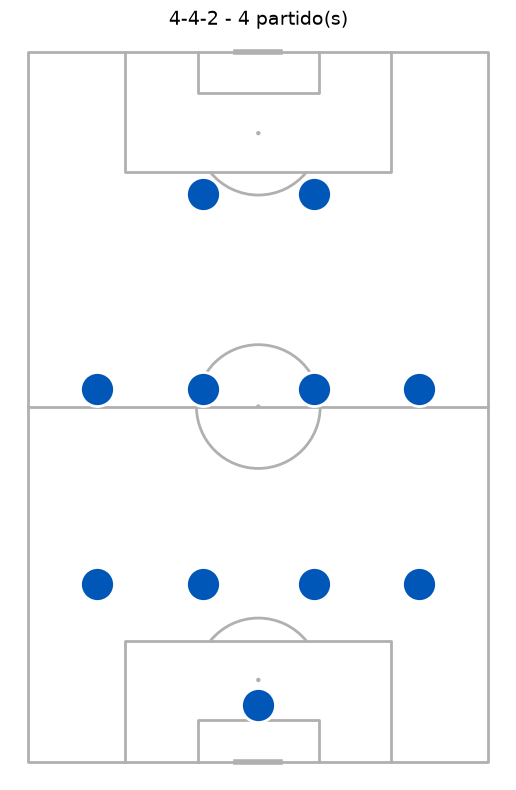

In [367]:
graficar_formacion(
    '4-4-2',
    4
)

## 3. Radiografía general de Boca en la Libertadores 2023
### ¿Boca era un equipo dominante o principalmente un equipo difícil de derrotar?

In [167]:
boca_partidos = partidos_boca_2023[
    partidos_boca_2023['equipo'] == 'Boca Juniors'
].copy()

rivales_partidos = partidos_boca_2023[
    partidos_boca_2023['equipo'] != 'Boca Juniors'
].copy()

In [168]:
metricas_generales = [
    'posesion',
    'xG',
    'remates',
    'remates_arco',
    'grandes_ocasiones',
    'pases',
    'precision_pases',
    'duelos_ganados',
    'tackles',
    'intercepciones',
    'despejes',
    'atajadas',
    'amarillas',
    'rojas',
    'goles'
]

In [169]:
comparacion_general = pd.DataFrame({
    'Boca': boca_partidos[metricas_generales].mean(),
    'Rivales': rivales_partidos[metricas_generales].mean()
})

comparacion_general.round(2)

,Boca,Rivales
posesion,53.77,46.23
xG,1.33,0.86
remates,11.92,11.77
remates_arco,4.46,3.46
grandes_ocasiones,1.92,0.92
pases,450.92,384.62
precision_pases,79.50,76.92
duelos_ganados,51.83,47.58
tackles,17.67,17.50
intercepciones,9.46,8.23


## 4. Fase de grupos vs. mata-mata
### ¿Cómo cambió Boca cuando comenzó la etapa eliminatoria?

In [170]:
boca_partidos['etapa'] = boca_partidos['fase'].apply(
    lambda x: 'Fase de grupos' if x == 'Grupos' else 'Mata-mata'
)

In [171]:
rivales_partidos['etapa'] = rivales_partidos['fase'].apply(
    lambda x: 'Fase de grupos' if x == 'Grupos' else 'Mata-mata'
)

In [172]:
comparacion_etapas_boca = (
    boca_partidos
    .groupby('etapa')[metricas_generales]
    .mean()
    .T
)

In [173]:
comparacion_etapas_boca.round(2)

etapa,Fase de grupos,Mata-mata
posesion,57.00,51.00
xG,1.70,1.02
remates,13.17,10.86
remates_arco,5.50,3.57
grandes_ocasiones,3.00,1.00
pases,453.33,448.86
precision_pases,82.00,77.00
duelos_ganados,56.33,47.33
tackles,21.17,14.17
intercepciones,11.50,7.71


In [174]:
comparacion_etapas_rivales = (
    rivales_partidos
    .groupby('etapa')[metricas_generales]
    .mean()
    .T
)

In [175]:
comparacion_etapas_rivales.round(2)

etapa,Fase de grupos,Mata-mata
posesion,43.00,49.00
xG,0.85,0.87
remates,11.33,12.14
remates_arco,3.33,3.57
grandes_ocasiones,0.67,1.14
pases,338.00,424.57
precision_pases,76.17,77.67
duelos_ganados,48.00,47.17
tackles,18.33,16.67
intercepciones,9.00,7.57


In [ ]:
pd.crosstab(
    formaciones_por_partido['formacion'],
    formaciones_por_partido['etapa']
)


In [166]:
formaciones_por_partido[
    ['fase', 'partido', 'formacion']
]

,fase,partido,formacion
0,Grupos,Monagas vs Boca,4-3-3
11,Grupos,Boca vs Deportivo Pereira,4-3-3
22,Grupos,Colo-Colo vs Boca,4-1-4-1
33,Grupos,Deportivo Pereira vs Boca,4-3-3
44,Grupos,Boca vs Colo-Colo,4-3-3
55,Grupos,Boca vs Monagas,4-3-3
66,Octavos,Nacional vs Boca,4-5-1
77,Octavos,Boca vs Nacional,4-4-2
88,Cuartos,Boca vs Racing,3-5-2
99,Cuartos,Racing vs Boca,5-3-2


In [176]:
titularidades_por_etapa = (
    alineaciones_boca_2023
    .groupby(['jugador', 'etapa'])
    .size()
    .unstack(fill_value=0)
)

In [177]:
titularidades_comparacion = titularidades_por_etapa.copy()

titularidades_comparacion['% grupos'] = (
    titularidades_comparacion['Fase de grupos'] / 6
) * 100

titularidades_comparacion['% mata-mata'] = (
    titularidades_comparacion['Mata-mata'] / 7
) * 100

titularidades_comparacion['cambio_pp'] = (
    titularidades_comparacion['% mata-mata']
    - titularidades_comparacion['% grupos']
)

titularidades_comparacion.sort_values(
    'cambio_pp',
    ascending=False
).round(1)

etapa,Fase de grupos,Mata-mata,% grupos,% mata-mata,cambio_pp
jugador,,,,,
Edinson Cavani,0,6,0.0,85.7,85.7
Ezequiel Fernández,0,5,0.0,71.4,71.4
Marcos Rojo,0,5,0.0,71.4,71.4
Miguel Merentiel,1,6,16.7,85.7,69.0
Cristian Medina,2,7,33.3,100.0,66.7
Frank Fabra,4,7,66.7,100.0,33.3
Luis Advíncula,4,7,66.7,100.0,33.3
Nicolás Valentini,2,4,33.3,57.1,23.8
Valentín Barco,3,5,50.0,71.4,21.4


In [178]:
contexto_jugadores = pd.DataFrame({
    'jugador': [
        'Alan Varela',
        'Sebastián Villa',
        'Edinson Cavani',
        'Óscar Romero',
        'Martín Payero',
        'Luca Langoni',
        'Norberto Briasco',
        'Marcos Rojo',
        'Ezequiel Fernández',
        'Miguel Merentiel',
        'Cristian Medina',
        'Valentín Barco'
    ],

    'contexto': [
        'Transferido al Porto',
        'Salida del club',
        'Incorporación después de fase de grupos',
        'Salida del club',
        'Fin de préstamo',
        'Lesiones',
        'Lesiones',
        'Regreso tras lesión / mayor disponibilidad',
        'Mayor protagonismo deportivo',
        'Mayor protagonismo deportivo',
        'Mayor protagonismo deportivo',
        'Mayor protagonismo deportivo'
    ]
})

In [179]:
titularidades_contexto = (
    titularidades_comparacion
    .reset_index()
    .merge(
        contexto_jugadores,
        on='jugador',
        how='left'
    )
)

In [180]:
titularidades_contexto.sort_values(
    'cambio_pp',
    ascending=False
)

,jugador,Fase de grupos,Mata-mata,% grupos,% mata-mata,cambio_pp,contexto
4,Edinson Cavani,0,6,0.000000,85.714286,85.714286,Incorporación después de fase de grupos
5,Ezequiel Fernández,0,5,0.000000,71.428571,71.428571,Mayor protagonismo deportivo
14,Marcos Rojo,0,5,0.000000,71.428571,71.428571,Regreso tras lesión / mayor disponibilidad
16,Miguel Merentiel,1,6,16.666667,85.714286,69.047619,Mayor protagonismo deportivo
2,Cristian Medina,2,7,33.333333,100.000000,66.666667,Mayor protagonismo deportivo
7,Frank Fabra,4,7,66.666667,100.000000,33.333333,NaN
11,Luis Advíncula,4,7,66.666667,100.000000,33.333333,NaN
18,Nicolás Valentini,2,4,33.333333,57.142857,23.809524,NaN
23,Valentín Barco,3,5,50.000000,71.428571,21.428571,Mayor protagonismo deportivo
17,Nicolás Figal,5,7,83.333333,100.000000,16.666667,NaN


In [181]:
boca_partidos[['partido', 'fase', 'etapa']]

,partido,fase,etapa
1,Nacional vs Boca,Octavos,Mata-mata
2,Boca vs Nacional,Octavos,Mata-mata
4,Boca vs Racing,Cuartos,Mata-mata
7,Racing vs Boca,Cuartos,Mata-mata
8,Boca vs Palmeiras,Semifinal,Mata-mata
11,Palmeiras vs Boca,Semifinal,Mata-mata
12,Boca vs Fluminense,Final,Mata-mata
15,Monagas vs Boca,Grupos,Fase de grupos
16,Boca vs Deportivo Pereira,Grupos,Fase de grupos
19,Colo-Colo vs Boca,Grupos,Fase de grupos


## 5. Análisis de jugadores

### ¿Quiénes fueron los jugadores más importantes de Boca en la Libertadores 2023?

In [182]:
jugadores_boca = boca_2023[
    boca_2023['minutesPlayed'] > 0
].copy()

In [183]:
jugadores_boca['90s'] = (
    jugadores_boca['minutesPlayed'] / 90
)

In [184]:
jugadores_boca['xG_por90'] = (
    jugadores_boca['expectedGoals'] /
    jugadores_boca['90s']
)

jugadores_boca['keyPasses_por90'] = (
    jugadores_boca['keyPasses'] /
    jugadores_boca['90s']
)

jugadores_boca['duelos_ganados_por90'] = (
    jugadores_boca['totalDuelsWon'] /
    jugadores_boca['90s']
)

jugadores_boca['intercepciones_por90'] = (
    jugadores_boca['interceptions'] /
    jugadores_boca['90s']
)

In [185]:
resumen_jugadores = jugadores_boca[
    [
        'player',
        'minutesPlayed',
        'appearances',
        'goals',
        'assists',
        'expectedGoals',
        'keyPasses',
        'accuratePasses',
        'accuratePassesPercentage',
        'totalDuelsWon',
        'interceptions',
        'tackles',
        'rating'
    ]
].sort_values(
    'minutesPlayed',
    ascending=False
)

In [186]:
resumen_jugadores

,player,minutesPlayed,appearances,goals,assists,expectedGoals,keyPasses,accuratePasses,accuratePassesPercentage,totalDuelsWon,interceptions,tackles,rating
24,Sergio Romero,1200,13,0,0,0.00,0,175,60.76,3,0,0,7.38
66,Pol Fernández,1182,13,0,0,0.76,20,607,84.42,51,13,28,6.98
55,Nicolás Figal,1058,12,0,0,0.56,3,418,81.17,48,14,17,7.00
72,Luis Advíncula,1028,12,4,1,0.34,10,299,80.81,65,5,22,7.18
27,Frank Fabra,979,11,0,1,0.51,11,381,78.88,47,27,22,6.91
17,Cristian Medina,862,11,0,1,1.56,10,371,90.49,40,3,12,6.65
0,Nicolás Valentini,674,11,0,0,0.56,3,296,77.69,34,6,9,6.85
49,Alan Varela,659,8,1,0,0.66,5,399,90.68,38,11,21,7.25
14,Valentín Barco,617,9,1,1,1.45,11,212,78.52,60,6,16,7.08
83,Miguel Merentiel,585,13,1,1,1.91,5,72,69.23,14,3,5,6.58


In [187]:
jug_nacional_boca_ida = armar_stats_jugadores(
    lineup_nacional_boca_ida,
    'Octavos',
    'Nacional vs Boca',
    'away'
)

jug_boca_nacional_vuelta = armar_stats_jugadores(
    lineup_boca_nacional_vuelta,
    'Octavos',
    'Boca vs Nacional',
    'home'
)

jug_boca_racing_ida = armar_stats_jugadores(
    lineup_boca_racing_ida,
    'Cuartos',
    'Boca vs Racing',
    'home'
)

jug_racing_boca_vuelta = armar_stats_jugadores(
    lineup_racing_boca_vuelta,
    'Cuartos',
    'Racing vs Boca',
    'away'
)

jug_boca_palmeiras_ida = armar_stats_jugadores(
    lineup_boca_palmeiras_ida,
    'Semifinal',
    'Boca vs Palmeiras',
    'home'
)

jug_palmeiras_boca_vuelta = armar_stats_jugadores(
    lineup_palmeiras_boca_vuelta,
    'Semifinal',
    'Palmeiras vs Boca',
    'away'
)

jug_boca_fluminense_final = armar_stats_jugadores(
    lineup_boca_fluminense_final,
    'Final',
    'Boca vs Fluminense',
    'home'
)

In [188]:
jug_monagas_boca = armar_stats_jugadores(
    lineup_monagas_boca,
    'Grupos',
    'Monagas vs Boca',
    'away'
)

jug_boca_pereira = armar_stats_jugadores(
    lineup_boca_pereira,
    'Grupos',
    'Boca vs Deportivo Pereira',
    'home'
)

jug_colo_colo_boca = armar_stats_jugadores(
    lineup_colo_colo_boca,
    'Grupos',
    'Colo-Colo vs Boca',
    'away'
)

jug_pereira_boca = armar_stats_jugadores(
    lineup_pereira_boca,
    'Grupos',
    'Deportivo Pereira vs Boca',
    'away'
)

jug_boca_colo_colo = armar_stats_jugadores(
    lineup_boca_colo_colo,
    'Grupos',
    'Boca vs Colo-Colo',
    'home'
)

jug_boca_monagas = armar_stats_jugadores(
    lineup_boca_monagas,
    'Grupos',
    'Boca vs Monagas',
    'home'
)

In [189]:
jugadores_mata_mata = pd.concat([
    jug_nacional_boca_ida,
    jug_boca_nacional_vuelta,
    jug_boca_racing_ida,
    jug_racing_boca_vuelta,
    jug_boca_palmeiras_ida,
    jug_palmeiras_boca_vuelta,
    jug_boca_fluminense_final
], ignore_index=True)

In [190]:
jugadores_grupos = pd.concat([
    jug_monagas_boca,
    jug_boca_pereira,
    jug_colo_colo_boca,
    jug_pereira_boca,
    jug_boca_colo_colo,
    jug_boca_monagas
], ignore_index=True)

In [191]:
jugadores_partido_boca_2023 = pd.concat([
    jugadores_grupos,
    jugadores_mata_mata
], ignore_index=True)

In [192]:
jugadores_grupos.shape
jugadores_mata_mata.shape
jugadores_partido_boca_2023.shape

(202, 26)

In [193]:
jugadores_partido_boca_2023.head()

,fase,partido,jugador,titular,posicion,minutos,rating,goles,asistencias,xG,...,duelos_ganados,regates_intentados,regates_exitosos,tackles,intercepciones,recuperaciones,despejes,perdidas,atajadas,goles_evitados
0,Grupos,Monagas vs Boca,Sergio Romero,True,G,90,7.3,0,0,0.0000,...,0,0,0,0,0,8,0,10,3,0.3168
1,Grupos,Monagas vs Boca,Nicolás Figal,True,D,90,7.6,0,0,0.0000,...,2,0,0,2,1,10,3,9,0,0.0000
2,Grupos,Monagas vs Boca,Facundo Roncaglia,True,D,86,6.1,0,0,0.0000,...,1,0,0,0,1,3,1,7,0,0.0000
3,Grupos,Monagas vs Boca,Bruno Valdez,True,D,40,5.6,0,0,0.0000,...,2,0,0,1,1,1,0,4,0,0.0000
4,Grupos,Monagas vs Boca,Frank Fabra,True,D,90,7.9,0,0,0.2198,...,8,4,4,4,6,11,0,23,0,0.0000


In [194]:
jugadores_partido_boca_2023['etapa'] = (
    jugadores_partido_boca_2023['fase']
    .apply(
        lambda x: 'Fase de grupos' if x == 'Grupos' else 'Mata-mata'
    )
)

In [195]:
minutos_por_etapa = (
    jugadores_partido_boca_2023
    .groupby(['jugador', 'etapa'])['minutos']
    .sum()
    .unstack(fill_value=0)
)

In [196]:
minutos_por_etapa.sort_values(
    'Mata-mata',
    ascending=False
)

etapa,Fase de grupos,Mata-mata
jugador,,
Sergio Romero,540,660
Frank Fabra,336,643
Pol Fernández,540,642
Cristian Medina,224,638
Luis Advíncula,405,623
Nicolás Figal,450,608
Edinson Cavani,0,509
Miguel Merentiel,139,446
Ezequiel Fernández,64,438


In [197]:
resumen_jugadores_etapa = (
    jugadores_partido_boca_2023
    .groupby(['jugador', 'etapa'])
    .agg(
        partidos=('partido', 'count'),
        minutos=('minutos', 'sum'),
        goles=('goles', 'sum'),
        asistencias=('asistencias', 'sum'),
        xG=('xG', 'sum'),
        xA=('xA', 'sum'),
        remates=('remates', 'sum'),
        remates_arco=('remates_arco', 'sum'),
        pases_clave=('pases_clave', 'sum'),
        pases=('pases', 'sum'),
        pases_acertados=('pases_acertados', 'sum'),
        duelos_ganados=('duelos_ganados', 'sum'),
        regates_exitosos=('regates_exitosos', 'sum'),
        tackles=('tackles', 'sum'),
        intercepciones=('intercepciones', 'sum'),
        recuperaciones=('recuperaciones', 'sum'),
        despejes=('despejes', 'sum'),
        perdidas=('perdidas', 'sum'),
        atajadas=('atajadas', 'sum'),
        goles_evitados=('goles_evitados', 'sum'),
        rating_promedio=('rating', 'mean')
    )
    .reset_index()
)

In [198]:
resumen_jugadores_etapa['90s'] = (
    resumen_jugadores_etapa['minutos'] / 90
)

In [223]:
resumen_jugadores_etapa['xG_por90'] = (
    resumen_jugadores_etapa['xG'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['xA_por90'] = (
    resumen_jugadores_etapa['xA'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['pases_clave_por90'] = (
    resumen_jugadores_etapa['pases_clave'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['duelos_ganados_por90'] = (
    resumen_jugadores_etapa['duelos_ganados'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['recuperaciones_por90'] = (
    resumen_jugadores_etapa['recuperaciones'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['atajadas_por90'] = (
    resumen_jugadores_etapa['atajadas'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['goles_evitados_por90'] = (
    resumen_jugadores_etapa['goles_evitados'] /
    resumen_jugadores_etapa['90s']
)

In [200]:
resumen_jugadores_etapa

,jugador,etapa,partidos,minutos,goles,asistencias,xG,xA,remates,remates_arco,...,perdidas,atajadas,goles_evitados,rating_promedio,90s,xG_por90,xA_por90,pases_clave_por90,duelos_ganados_por90,recuperaciones_por90
0,Agustín Sández,Fase de grupos,1,24,0,0,0.1648,0.006170,1,1,...,5,0,0.0000,6.800000,0.266667,0.618000,0.023138,0.000000,3.750000,3.750000
1,Alan Varela,Fase de grupos,6,483,1,0,0.3306,0.577675,7,3,...,37,0,0.0000,7.383333,5.366667,0.061602,0.107641,0.745342,4.658385,5.776398
2,Alan Varela,Mata-mata,2,176,0,0,0.3284,0.035942,1,0,...,16,0,0.0000,6.850000,1.955556,0.167932,0.018380,0.511364,6.647727,7.159091
3,Bruno Valdez,Fase de grupos,3,166,0,0,0.0965,0.005353,1,0,...,21,0,0.0000,6.100000,1.844444,0.052319,0.002902,0.000000,4.879518,3.795181
4,Bruno Valdez,Mata-mata,3,89,0,0,0.0000,0.004452,0,0,...,11,0,0.0000,6.433333,0.988889,0.000000,0.004502,0.000000,2.022472,3.033708
5,Cristian Medina,Fase de grupos,4,224,0,0,1.0544,0.136832,3,1,...,21,0,0.0000,6.650000,2.488889,0.423643,0.054977,0.803571,6.428571,5.223214
6,Cristian Medina,Mata-mata,7,638,0,1,0.5072,0.266163,8,3,...,78,0,0.0000,6.642857,7.088889,0.071549,0.037547,1.128527,3.385580,5.501567
7,Darío Benedetto,Fase de grupos,4,291,0,0,0.2157,0.207930,6,1,...,38,0,0.0000,6.800000,3.233333,0.066711,0.064308,1.237113,5.257732,2.474227
8,Darío Benedetto,Mata-mata,4,75,0,0,0.4461,0.094503,4,0,...,7,0,0.0000,6.700000,0.833333,0.535320,0.113403,2.400000,0.000000,1.200000
9,Edinson Cavani,Mata-mata,6,509,1,0,1.9372,0.414693,10,4,...,67,0,0.0000,6.666667,5.655556,0.342530,0.073325,0.707269,4.243615,4.774067


In [201]:
resumen_jugadores_etapa['precision_pases'] = (
    resumen_jugadores_etapa['pases_acertados'] /
    resumen_jugadores_etapa['pases']
) * 100

In [202]:
resumen_jugadores_etapa['remates_por90'] = (
    resumen_jugadores_etapa['remates'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['regates_exitosos_por90'] = (
    resumen_jugadores_etapa['regates_exitosos'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['tackles_por90'] = (
    resumen_jugadores_etapa['tackles'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['intercepciones_por90'] = (
    resumen_jugadores_etapa['intercepciones'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['despejes_por90'] = (
    resumen_jugadores_etapa['despejes'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['perdidas_por90'] = (
    resumen_jugadores_etapa['perdidas'] /
    resumen_jugadores_etapa['90s']
)

### 5.1 Mediocampistas

¿Cómo cambió el mediocampo de Boca entre la fase de grupos y las eliminatorias?

In [203]:
mediocampistas = [
    'Cristian Medina',
    'Ezequiel Fernández',
    'Pol Fernández',
    'Alan Varela',
    'Jorman Campuzano'
]

In [204]:
comparacion_mediocampistas = (
    resumen_jugadores_etapa[
        resumen_jugadores_etapa['jugador'].isin(mediocampistas)
    ]
    [
        [
            'jugador',
            'etapa',
            'partidos',
            'minutos',
            'goles',
            'asistencias',
            'xG_por90',
            'xA_por90',
            'pases_clave_por90',
            'precision_pases',
            'duelos_ganados_por90',
            'tackles_por90',
            'intercepciones_por90',
            'recuperaciones_por90',
            'perdidas_por90'
        ]
    ]
    .sort_values(['jugador', 'etapa'])
)

In [205]:
comparacion_mediocampistas.round(2)

,jugador,etapa,partidos,minutos,goles,asistencias,xG_por90,xA_por90,pases_clave_por90,precision_pases,duelos_ganados_por90,tackles_por90,intercepciones_por90,recuperaciones_por90,perdidas_por90
1,Alan Varela,Fase de grupos,6,483,1,0,0.06,0.11,0.75,91.38,4.66,3.17,1.49,5.78,6.89
2,Alan Varela,Mata-mata,2,176,0,0,0.17,0.02,0.51,88.70,6.65,2.05,1.53,7.16,8.18
5,Cristian Medina,Fase de grupos,4,224,0,0,0.42,0.05,0.80,91.87,6.43,1.61,0.40,5.22,8.44
6,Cristian Medina,Mata-mata,7,638,0,1,0.07,0.04,1.13,89.90,3.39,1.13,0.28,5.50,11.00
12,Ezequiel Fernández,Fase de grupos,3,64,0,0,0.06,0.04,2.81,90.12,4.22,2.81,1.41,15.47,19.69
13,Ezequiel Fernández,Mata-mata,5,438,0,0,0.03,0.02,1.03,85.29,8.22,2.88,0.62,8.42,11.92
17,Jorman Campuzano,Mata-mata,3,67,0,0,0.00,0.02,0.00,84.21,13.43,4.03,1.34,14.78,16.12
37,Pol Fernández,Fase de grupos,6,540,0,0,0.11,0.13,1.50,84.80,4.33,2.33,1.67,6.33,10.17
38,Pol Fernández,Mata-mata,7,642,0,0,0.01,0.06,1.54,84.16,3.50,1.96,0.42,7.01,11.50


**Lectura inicial:** el mediocampo de Boca cambió considerablemente entre la fase de grupos y las eliminatorias.
Alan Varela había sido una de las piezas más estables durante la fase de grupos, disputando 483 minutos en los seis partidos y mostrando una precisión de pase superior al 91%. Todavía participó en el primer cruce del mata-mata, acumulando 176 minutos, antes de su transferencia al Porto. Su salida modificó la estructura del mediocampo y coincidió con el crecimiento del protagonismo de Ezequiel Fernández.
Equi pasó de disputar solamente 64 minutos en la fase de grupos a acumular 438 minutos durante las eliminatorias. Debido a su escasa participación inicial, sus métricas por 90 en grupos deben interpretarse con cautela. En el mata-mata se destacó especialmente por su aporte en los duelos, con 8.22 ganados por 90 minutos, además de 2.88 tackles y 8.42 recuperaciones por 90, consolidándose como una pieza importante en el centro del campo.
Cristian Medina también aumentó considerablemente su participación, pasando de 224 a 638 minutos. Su xG por 90 disminuyó, pero aumentaron sus pases clave, muchas veces jugando recostado sobre la derecha dentro del 4-4-2, el esquema más utilizado por Almirón durante el mata-mata. Esto sugiere una menor participación como finalizador y un mayor peso en la circulación y creación desde ese sector.
Pol Fernández, definido por Riquelme como uno de los jugadores más inteligentes del fútbol argentino, se mantuvo como una de las piezas más estables durante toda la competición. Sus minutos, precisión de pase y producción de pases clave se mantuvieron relativamente constantes entre ambas etapas, funcionando como un punto de continuidad dentro de un mediocampo que sufrió varios cambios.
Jorman Campuzano reapareció durante el mata-mata, aunque con un papel secundario: disputó solamente 67 minutos repartidos en tres partidos. Por lo tanto, sus elevados registros por 90, especialmente en duelos y recuperaciones, deben interpretarse con cautela debido al reducido tamaño de la muestra.
En conjunto, el mediocampo de las eliminatorias fue diferente al de la fase de grupos. La salida de Varela, la consolidación de Equi Fernández, el fuerte aumento de protagonismo de Medina y la continuidad de Pol modificaron la composición del centro del campo. Estos cambios coincidieron con un Boca de menor producción ofensiva colectiva y con partidos mucho más equilibrados durante el mata-mata.

### 5.2 Jugadores de banda

¿Cómo cambiaron Advíncula, Barco y Fabra entre la fase de grupos y el mata-mata?

In [206]:
jugadores_banda = [
    'Luis Advíncula',
    'Valentín Barco',
    'Frank Fabra'
]

In [207]:
comparacion_banda = (
    resumen_jugadores_etapa[
        resumen_jugadores_etapa['jugador'].isin(jugadores_banda)
    ]
    [
        [
            'jugador',
            'etapa',
            'partidos',
            'minutos',
            'goles',
            'asistencias',
            'xG_por90',
            'xA_por90',
            'pases_clave_por90',
            'precision_pases',
            'regates_exitosos_por90',
            'duelos_ganados_por90',
            'tackles_por90',
            'intercepciones_por90',
            'recuperaciones_por90',
            'perdidas_por90'
        ]
    ]
    .sort_values(['jugador', 'etapa'])
)

In [208]:
comparacion_banda.round(2)

,jugador,etapa,partidos,minutos,goles,asistencias,xG_por90,xA_por90,pases_clave_por90,precision_pases,regates_exitosos_por90,duelos_ganados_por90,tackles_por90,intercepciones_por90,recuperaciones_por90,perdidas_por90
15,Frank Fabra,Fase de grupos,4,336,0,1,0.07,0.06,1.88,79.58,1.61,4.29,2.41,4.02,7.50,16.61
16,Frank Fabra,Mata-mata,7,643,0,0,0.03,0.05,0.56,78.42,0.56,4.34,1.82,1.68,6.58,14.14
22,Luis Advíncula,Fase de grupos,5,405,2,0,0.03,0.04,0.44,81.25,1.56,6.67,2.44,0.67,6.44,12.00
23,Luis Advíncula,Mata-mata,7,623,2,1,0.03,0.19,1.16,80.48,0.87,5.06,1.59,0.29,4.77,12.42
42,Valentín Barco,Fase de grupos,3,250,1,1,0.35,0.35,2.16,77.48,3.24,12.96,5.04,1.44,8.64,19.44
43,Valentín Barco,Mata-mata,6,367,0,0,0.12,0.28,1.23,79.25,2.21,6.13,0.49,0.49,5.15,22.32


**Lectura inicial:** el comportamiento de los jugadores de banda cambió considerablemente en las eliminatorias.
Luis Advíncula aumentó su incidencia ofensiva durante el mata-mata. Mantuvo su producción goleadora y elevó tanto su xA como sus pases clave por 90 minutos, convirtiéndose en una fuente importante de creación desde el sector derecho. Al mismo tiempo, algunas métricas como regates, duelos y recuperaciones disminuyeron, lo que puede estar relacionado con un cambio en su función dentro del equipo y con un mayor peso en acciones ofensivas concretas.
Frank Fabra, en cambio, redujo considerablemente su participación creativa respecto de la fase de grupos. Sus pases clave y regates exitosos por 90 minutos disminuyeron, al igual que varias de sus métricas defensivas. A pesar de esto, mantuvo valores relativamente estables en precisión de pase y duelos ganados.
Valentín Barco también presentó una caída en varias métricas por 90, especialmente en xG, pases clave, regates y duelos ganados. Sin embargo, mantuvo una producción relevante de xA y su impacto en el mata-mata no se explica completamente a través de estas estadísticas.
Barco fue uno de los jugadores que aportó mayor rebeldía y frescura al equipo. Tuvo momentos de mucha influencia individual, como en el partido de vuelta frente a Palmeiras en Brasil, donde generó dificultades constantes para los defensores rivales mediante sus conducciones y su capacidad para romper líneas. Además, asumió la responsabilidad de ejecutar el penal decisivo en la definición frente a Nacional.
Su caso muestra la importancia de complementar las métricas con el análisis de contexto y video: aunque varios de sus indicadores por 90 disminuyeron respecto de la fase de grupos, tuvo intervenciones de gran peso en momentos decisivos del recorrido de Boca.
En conjunto, los datos muestran que el peso ofensivo de las bandas se redistribuyó durante las eliminatorias, con Advíncula ganando protagonismo como generador desde el sector derecho y Barco aportando desequilibrio e influencia en momentos clave, aun cuando algunas de sus métricas por 90 fueron inferiores a las registradas en la fase de grupos.

### 5.3 Delanteros

¿Cómo cambió la producción y la composición del ataque de Boca entre la fase de grupos y el mata-mata?

In [212]:
resumen_jugadores_etapa['goles_menos_xG'] = (
    resumen_jugadores_etapa['goles'] -
    resumen_jugadores_etapa['xG']
)

resumen_jugadores_etapa['goles_menos_xG_por90'] = (
    resumen_jugadores_etapa['goles_menos_xG'] /
    resumen_jugadores_etapa['90s']
)

In [216]:
resumen_jugadores_etapa['goles_por90'] = (
    resumen_jugadores_etapa['goles'] /
    resumen_jugadores_etapa['90s']
)

resumen_jugadores_etapa['remates_arco_por90'] = (
    resumen_jugadores_etapa['remates_arco'] /
    resumen_jugadores_etapa['90s']
)

In [213]:
delanteros = [
    'Edinson Cavani',
    'Miguel Merentiel',
    'Darío Benedetto',
    'Luis Vázquez',
    'Sebastián Villa'
]

In [217]:
comparacion_delanteros = (
    resumen_jugadores_etapa[
        resumen_jugadores_etapa['jugador'].isin(delanteros)
    ]
    [
        [
            'jugador',
            'etapa',
            'partidos',
            'minutos',
            'goles',
            'asistencias',
            'goles_por90',
            'xG_por90',
            'goles_menos_xG',
            'goles_menos_xG_por90',
            'xA_por90',
            'remates_por90',
            'remates_arco_por90',
            'pases_clave_por90',
            'precision_pases',
            'duelos_ganados_por90',
            'perdidas_por90'
        ]
    ]
    .sort_values(['jugador', 'etapa'])
)

In [218]:
comparacion_delanteros.round(2)

,jugador,etapa,partidos,minutos,goles,asistencias,goles_por90,xG_por90,goles_menos_xG,goles_menos_xG_por90,xA_por90,remates_por90,remates_arco_por90,pases_clave_por90,precision_pases,duelos_ganados_por90,perdidas_por90
7,Darío Benedetto,Fase de grupos,4,291,0,0,0.00,0.07,-0.22,-0.07,0.06,1.86,0.31,1.24,65.45,5.26,11.75
8,Darío Benedetto,Mata-mata,4,75,0,0,0.00,0.54,-0.45,-0.54,0.11,4.80,0.00,2.40,82.35,0.00,8.40
9,Edinson Cavani,Mata-mata,6,509,1,0,0.18,0.34,-0.94,-0.17,0.07,1.77,0.71,0.71,74.00,4.24,11.85
24,Luis Vázquez,Fase de grupos,5,140,2,1,1.29,1.54,-0.39,-0.25,0.05,5.14,4.50,1.93,69.44,5.14,11.57
30,Miguel Merentiel,Fase de grupos,6,139,0,0,0.00,0.10,-0.15,-0.10,0.03,0.65,0.00,0.65,78.26,2.59,9.06
31,Miguel Merentiel,Mata-mata,7,446,1,1,0.20,0.35,-0.75,-0.15,0.18,2.22,0.81,0.81,66.67,2.02,11.10
39,Sebastián Villa,Fase de grupos,4,360,1,1,0.25,0.20,0.21,0.05,0.21,2.25,1.00,2.00,76.11,9.00,22.25


**Lectura inicial:** el frente de ataque de Boca sufrió una transformación importante entre la fase de grupos y las eliminatorias.
Durante la fase de grupos, Sebastián Villa, Darío Benedetto y Luis Vázquez tuvieron participación relevante. Villa aportó un gol y una asistencia, además de una producción importante de pases clave. Vázquez convirtió dos goles en apenas 140 minutos, aunque sus elevados registros por 90 deben interpretarse con cautela debido a su reducido tiempo de juego. Benedetto, por su parte, acumuló 291 minutos sin convertir y con una producción de xG relativamente baja.
La composición ofensiva cambió sustancialmente en el mata-mata. Edinson Cavani se incorporó al equipo y Miguel Merentiel aumentó considerablemente su protagonismo, mientras Villa y Vázquez dejaron de formar parte de la rotación habitual y Benedetto tuvo una participación mucho menor.
Cavani disputó 509 minutos durante las eliminatorias y convirtió un gol, pese a acumular aproximadamente 1.94 xG. Esto representa una diferencia de -0.94 entre goles y xG y muestra que convirtió por debajo de lo esperado según la calidad de las ocasiones que tuvo.
Merentiel también ganó peso dentro del equipo: pasó de 139 minutos en grupos a 446 en el mata-mata, aumentando considerablemente su xG y su volumen de remates. Aportó un gol y una asistencia, aunque también finalizó por debajo de su producción esperada, con aproximadamente 1.75 xG y un gol.
Por lo tanto, la caída goleadora de Boca durante las eliminatorias parece combinar dos fenómenos: una reducción en la generación ofensiva colectiva y una menor eficacia en la definición de sus principales delanteros. A esto se suma una transformación casi completa del frente de ataque entre ambas etapas.

### 5.4 Defensores centrales

¿Cómo cambió la estructura defensiva de Boca entre la fase de grupos y las eliminatorias?

In [219]:
centrales = [
    'Marcos Rojo',
    'Nicolás Figal',
    'Nicolás Valentini',
    'Bruno Valdez',
    'Facundo Roncaglia'
]

In [220]:
comparacion_centrales = (
    resumen_jugadores_etapa[
        resumen_jugadores_etapa['jugador'].isin(centrales)
    ]
    [
        [
            'jugador',
            'etapa',
            'partidos',
            'minutos',
            'precision_pases',
            'duelos_ganados_por90',
            'tackles_por90',
            'intercepciones_por90',
            'recuperaciones_por90',
            'despejes_por90',
            'perdidas_por90'
        ]
    ]
    .sort_values(['jugador', 'etapa'])
)

In [221]:
comparacion_centrales.round(2)

,jugador,etapa,partidos,minutos,precision_pases,duelos_ganados_por90,tackles_por90,intercepciones_por90,recuperaciones_por90,despejes_por90,perdidas_por90
3,Bruno Valdez,Fase de grupos,3,166,81.65,4.88,1.63,2.17,3.80,4.34,11.39
4,Bruno Valdez,Mata-mata,3,89,71.79,2.02,0.00,0.00,3.03,2.02,11.12
14,Facundo Roncaglia,Fase de grupos,4,266,85.00,3.05,1.35,2.37,4.06,3.38,7.11
28,Marcos Rojo,Mata-mata,6,375,76.36,4.08,0.96,0.96,4.80,3.36,12.96
32,Nicolás Figal,Fase de grupos,5,450,84.92,5.00,1.60,1.00,4.80,3.00,9.00
33,Nicolás Figal,Mata-mata,7,608,77.57,3.40,1.33,1.33,5.33,4.14,11.40
34,Nicolás Valentini,Fase de grupos,4,270,84.48,4.00,1.33,1.00,2.33,7.33,9.67
35,Nicolás Valentini,Mata-mata,7,404,71.98,4.90,1.11,0.67,4.68,5.57,14.03


**Lectura inicial:** la composición de la defensa central de Boca también cambió entre la fase de grupos y las eliminatorias.
Nicolás Figal fue la principal pieza de continuidad, con una participación elevada en ambas etapas. A su alrededor, sin embargo, los acompañantes fueron modificándose: Facundo Roncaglia y Bruno Valdez tuvieron mayor presencia durante la fase de grupos, mientras que Marcos Rojo se incorporó con mayor protagonismo en el mata-mata y Nicolás Valentini también aumentó sus minutos.
En las eliminatorias se observa además una caída general en la precisión de pase de los centrales. Figal pasó de 84.92% a 77.57% y Valentini de 84.48% a 71.98%, mientras Rojo registró 76.36%. Esto podría estar relacionado con un contexto de mayor presión rival, una salida menos limpia o un juego más directo, aunque estas hipótesis deberán contrastarse posteriormente con el análisis de los partidos.
Figal aumentó ligeramente sus recuperaciones y despejes por 90 minutos, aunque disminuyó su cantidad de duelos ganados. Valentini, por su parte, incrementó su participación en duelos y recuperaciones durante el mata-mata, pero también aumentó considerablemente sus pérdidas de posesión.
Los registros de Bruno Valdez en las eliminatorias deben interpretarse con cautela debido a que disputó solamente 89 minutos.
Finalmente, el caso de Marcos Rojo requiere un análisis contextual particular. Su regreso le permitió convertirse en una pieza importante de la defensa durante las eliminatorias, pero su expulsión en la semifinal de vuelta frente a Palmeiras condicionó de manera decisiva uno de los partidos más importantes del recorrido.
En conjunto, Boca afrontó el mata-mata con una zaga diferente a la utilizada durante buena parte de la fase de grupos, con Figal como elemento de continuidad y una mayor presencia de Rojo y Valentini.

### 5.5 Sergio Romero

¿Cuánto influyó Sergio Romero en el recorrido de Boca hacia la final?

#### 5.5.1 Rendimiento durante los partidos


In [224]:
comparacion_romero = (
    resumen_jugadores_etapa[
        resumen_jugadores_etapa['jugador'] == 'Sergio Romero'
    ]
    [
        [
            'etapa',
            'partidos',
            'minutos',
            'atajadas',
            'atajadas_por90',
            'goles_evitados',
            'goles_evitados_por90',
            'rating_promedio'
        ]
    ]
)

In [225]:
comparacion_romero.round(2)

,etapa,partidos,minutos,atajadas,atajadas_por90,goles_evitados,goles_evitados_por90,rating_promedio
40,Fase de grupos,6,540,18,3.00,2.90,0.48,7.38
41,Mata-mata,7,660,20,2.73,0.27,0.04,7.39


**Lectura inicial:** el rendimiento de Sergio Romero durante el juego no presentó grandes diferencias entre la fase de grupos y las eliminatorias.
En la fase de grupos realizó 18 atajadas en 540 minutos, equivalentes a 3.00 por 90 minutos, mientras que en el mata-mata registró 20 atajadas en 660 minutos, con un promedio ligeramente inferior de 2.73 por 90. Su rating promedio también se mantuvo prácticamente idéntico entre ambas etapas (7.38 frente a 7.39).
Una diferencia importante aparece en la métrica de goles evitados. Romero acumuló 2.90 durante la fase de grupos, mientras que en las eliminatorias registró solamente 0.27. Esto sugiere que, según esta métrica de SofaScore, su impacto como atajador durante el desarrollo de los partidos fue incluso mayor en la primera etapa de la competición.
Por lo tanto, los datos no muestran que Romero haya tenido que sostener a Boca mediante un volumen extraordinariamente mayor de atajadas durante las eliminatorias. Su rendimiento dentro de los partidos fue estable y de buen nivel, pero no sufrió un salto evidente respecto de la fase de grupos.
Esto hace todavía más relevante analizar por separado las definiciones por penales, ya que allí parece concentrarse una parte fundamental de su impacto diferencial en el camino de Boca hacia la final.

#### 5.5.2 Impacto en las definiciones por penales

In [ ]:
url_penales_romero = (
    'https://www.elgrafico.com.ar/articulo/primera-division/'
    '61453/cuantos-penales-atajo-sergio-romero-en-toda-su-carrera'
)

headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/151.0.0.0 Safari/537.36'
    )
}

respuesta = requests.get(
    url_penales_romero,
    headers=headers,
    timeout=30
)

print(respuesta.status_code)

tablas_romero = pd.read_html(
    StringIO(respuesta.text)
)


In [231]:
len(tablas_romero)

5

In [232]:
for i, tabla in enumerate(tablas_romero):
    print(i, tabla.columns.tolist())

0 [0, 1, 2, 3, 4, 5]
1 [0, 1, 2, 3, 4, 5, 6]
2 [0, 1, 2, 3, 4, 5]
3 [0, 1, 2, 3, 4, 5]
4 [0, 1, 2, 3, 4, 5, 6, 7]


In [ ]:
tabla_penales_romero = tablas_romero[4].copy()#viendo la ejecucion anterior veo que la 4 es la que tiene 8 elementos que coincide con lo de la pagina

tabla_penales_romero.head(10)

,0,1,2,3,4,5,6,7
0,#,FECHA,TORNEO,LOCAL,RESULTADO,VISITANTE,TIEMPO,RESOLUCIÓN
1,1,30/09/2007,Eredivisie 2008/09,Heracles Almelo,2 - 1,AZ Alkmaar,Regular,Convertido
2,2,02/12/2007,Eredivisie 2008/09,AZ Alkmaar,6 - 0,Sparta Rotterdam,Regular,Atajado
3,3,17/02/2008,Eredivisie 2008/09,FC Groningen,2 - 1,AZ Alkmaar,Regular,Convertido
4,4,06/04/2008,Eredivisie 2008/09,VVV-Venlo,2 - 3,AZ Alkmaar,Regular,Convertido
5,5,03/10/2008,Eredivisie 2008/09,FC Twente,2 - 1,AZ Alkmaar,Regular,Atajado
6,6,26/04/2009,Eredivisie 2008/09,Ajax,1 - 1,AZ Alkmaar,Regular,Convertido
7,7,05/02/2011,Eredivisie 2008/09,Excelsior Rotterdam,2 - 1,AZ Alkmaar,Regular,Convertido
8,8,09/04/2011,Eredivisie 2008/09,AZ Alkmaar,1 - 1,NAC Breda,Regular,Convertido
9,9,29/10/2011,Serie B 2011/12,ASG Nocerina,4 - 2,Sampdoria,Regular,Convertido


In [234]:
tabla_penales_romero.columns = tabla_penales_romero.iloc[0]

tabla_penales_romero = (
    tabla_penales_romero
    .iloc[1:]
    .reset_index(drop=True)
)

In [235]:
tabla_penales_romero.head()

,#,FECHA,TORNEO,LOCAL,RESULTADO,VISITANTE,TIEMPO,RESOLUCIÓN
0,1,30/09/2007,Eredivisie 2008/09,Heracles Almelo,2 - 1,AZ Alkmaar,Regular,Convertido
1,2,02/12/2007,Eredivisie 2008/09,AZ Alkmaar,6 - 0,Sparta Rotterdam,Regular,Atajado
2,3,17/02/2008,Eredivisie 2008/09,FC Groningen,2 - 1,AZ Alkmaar,Regular,Convertido
3,4,06/04/2008,Eredivisie 2008/09,VVV-Venlo,2 - 3,AZ Alkmaar,Regular,Convertido
4,5,03/10/2008,Eredivisie 2008/09,FC Twente,2 - 1,AZ Alkmaar,Regular,Atajado


In [236]:
tabla_penales_romero.columns = [
    'numero',
    'fecha',
    'torneo',
    'local',
    'resultado',
    'visitante',
    'tiempo',
    'resolucion'
]

In [237]:
tabla_penales_romero['fecha'] = pd.to_datetime(
    tabla_penales_romero['fecha'],
    dayfirst=True
)

In [238]:
tabla_penales_romero.shape

(121, 8)

In [239]:
tabla_penales_romero['tiempo'].value_counts()

tiempo
Definición    71
Regular       50
Name: count, dtype: int64

In [240]:
tabla_penales_romero['resolucion'].value_counts()

resolucion
Convertido    86
Atajado       29
Desviado       6
Name: count, dtype: int64

In [241]:
tabla_penales_romero[
    tabla_penales_romero['torneo'].str.contains(
        'Libertadores',
        case=False,
        na=False
    )
]['torneo'].value_counts()

torneo
Copa Libertadores 2023    12
Name: count, dtype: int64

In [242]:
penales_libertadores_2023 = tabla_penales_romero[
    tabla_penales_romero['torneo'].str.contains(
        'Libertadores 2023',
        case=False,
        na=False
    )
].copy()

In [243]:
penales_libertadores_2023

,numero,fecha,torneo,local,resultado,visitante,tiempo,resolucion
83,84,2023-05-24,Copa Libertadores 2023,Deportivo Pereira,1 - 0,Boca,Regular,Atajado
86,87,2023-08-09,Copa Libertadores 2023,Boca,2 - 2,Nacional,Definición,Atajado
87,88,2023-08-09,Copa Libertadores 2023,Boca,2 - 2,Nacional,Definición,Convertido
88,89,2023-08-09,Copa Libertadores 2023,Boca,2 - 2,Nacional,Definición,Atajado
89,90,2023-08-09,Copa Libertadores 2023,Boca,2 - 2,Nacional,Definición,Convertido
90,91,2023-08-30,Copa Libertadores 2023,Racing,0 - 0,Boca,Definición,Atajado
91,92,2023-08-30,Copa Libertadores 2023,Racing,0 - 0,Boca,Definición,Convertido
92,93,2023-08-30,Copa Libertadores 2023,Racing,0 - 0,Boca,Definición,Atajado
98,99,2023-10-05,Copa Libertadores 2023,Palmeiras,1 - 1,Boca,Definición,Atajado
99,100,2023-10-05,Copa Libertadores 2023,Palmeiras,1 - 1,Boca,Definición,Atajado


In [244]:
### libertadores para comparar
inicio_libertadores_2023 = pd.Timestamp('2023-04-06')
fin_libertadores_2023 = pd.Timestamp('2023-11-04')

In [245]:
penales_antes_libertadores = tabla_penales_romero[
    tabla_penales_romero['fecha'] < inicio_libertadores_2023
].copy()

penales_durante_otras_competiciones = tabla_penales_romero[
    (tabla_penales_romero['fecha'] >= inicio_libertadores_2023) &
    (tabla_penales_romero['fecha'] <= fin_libertadores_2023) &
    (tabla_penales_romero['torneo'] != 'Copa Libertadores 2023')
].copy()

penales_despues_libertadores = tabla_penales_romero[
    tabla_penales_romero['fecha'] > fin_libertadores_2023
].copy()

penales_resto_carrera = tabla_penales_romero[
    tabla_penales_romero['torneo'] != 'Copa Libertadores 2023'
].copy()

In [247]:
comparacion_penales_romero = pd.DataFrame({
    'Antes de Libertadores 2023':
        resumir_penales(penales_antes_libertadores),

    'Libertadores 2023':
        resumir_penales(penales_libertadores_2023),

    'Durante Libertadores - otras competiciones':
        resumir_penales(penales_durante_otras_competiciones),

    'Después de Libertadores 2023':
        resumir_penales(penales_despues_libertadores),

    'Resto de su carrera':
        resumir_penales(penales_resto_carrera),

    'Toda su carrera':
        resumir_penales(tabla_penales_romero)
}).T

In [248]:
comparacion_penales_romero.round(2)

,total,atajados,convertidos,desviados,pct_atajados,pct_no_convertidos,pct_atajados_al_arco
Antes de Libertadores 2023,82.0,17.0,61.0,4.0,20.73,25.61,21.79
Libertadores 2023,12.0,7.0,5.0,0.0,58.33,58.33,58.33
Durante Libertadores - otras competiciones,11.0,3.0,6.0,2.0,27.27,45.45,33.33
Después de Libertadores 2023,16.0,2.0,14.0,0.0,12.50,12.50,12.50
Resto de su carrera,109.0,22.0,81.0,6.0,20.18,25.69,21.36
Toda su carrera,121.0,29.0,86.0,6.0,23.97,28.93,25.22


In [249]:
comparacion_libertadores_tipo = (
    penales_libertadores_2023
    .groupby('tiempo')
    .apply(
        lambda df: pd.Series(resumir_penales(df)),
        include_groups=False
    )
)

comparacion_libertadores_tipo.round(2)

,total,atajados,convertidos,desviados,pct_atajados,pct_no_convertidos,pct_atajados_al_arco
tiempo,,,,,,,
Definición,11.0,6.0,5.0,0.0,54.55,54.55,54.55
Regular,1.0,1.0,0.0,0.0,100.00,100.00,100.00


In [251]:
total_libertadores = pd.DataFrame(
    [resumir_penales(penales_libertadores_2023)],
    index=['Total']
)

comparacion_libertadores_tipo = pd.concat([
    comparacion_libertadores_tipo,
    total_libertadores
])

comparacion_libertadores_tipo.round(2)

,total,atajados,convertidos,desviados,pct_atajados,pct_no_convertidos,pct_atajados_al_arco
Definición,11.0,6.0,5.0,0.0,54.55,54.55,54.55
Regular,1.0,1.0,0.0,0.0,100.00,100.00,100.00
Total,12.0,7.0,5.0,0.0,58.33,58.33,58.33


In [252]:
penales_definicion_libertadores = penales_libertadores_2023[
    penales_libertadores_2023['tiempo'] == 'Definición'
].copy()

penales_definicion_resto_carrera = tabla_penales_romero[
    (tabla_penales_romero['tiempo'] == 'Definición') &
    (tabla_penales_romero['torneo'] != 'Copa Libertadores 2023')
].copy()

In [253]:
comparacion_tandas_romero = pd.DataFrame({
    'Libertadores 2023':
        resumir_penales(penales_definicion_libertadores),

    'Resto de las tandas de su carrera':
        resumir_penales(penales_definicion_resto_carrera)
}).T

comparacion_tandas_romero.round(2)

,total,atajados,convertidos,desviados,pct_atajados,pct_no_convertidos,pct_atajados_al_arco
Libertadores 2023,11.0,6.0,5.0,0.0,54.55,54.55,54.55
Resto de las tandas de su carrera,60.0,9.0,46.0,5.0,15.00,23.33,16.36


#### 5.5.3 ¿Qué tan excepcional fue atajar 6 de 11?
Si Romero tuviera en cada penal una probabilidad de atajar igual a la registrada en el resto de las tandas de su carrera, 15%, ¿qué probabilidad habría de que atajara 6 o más de 11 penales?

In [ ]:
prob_6_o_mas = binom.sf(
    5,
    11,
    0.15
)

prob_6_o_mas

print(f"{prob_6_o_mas * 100:.3f}%")


In [257]:
penales_definicion_antes = tabla_penales_romero[
    (tabla_penales_romero['tiempo'] == 'Definición') &
    (tabla_penales_romero['fecha'] < inicio_libertadores_2023)
].copy()

p_antes = (
    (penales_definicion_antes['resolucion'] == 'Atajado').sum()
    / len(penales_definicion_antes)
)

print(f"{p_antes * 100:.2f}%")

15.79%


In [258]:
prob_6_o_mas_antes = binom.sf(
    5,
    11,
    p_antes
)

print(f"{prob_6_o_mas_antes * 100:.3f}%")

0.348%


**Lectura:** el rendimiento de Sergio Romero en las definiciones por penales de la Libertadores 2023 fue extraordinariamente superior a sus antecedentes habituales.
Tomando como referencia el 15% de penales atajados por Romero en el resto de las tandas de su carrera, la probabilidad de que atajara al menos 6 de 11 penales bajo un modelo binomial es de aproximadamente 0,266%.
También puede realizarse una comparación utilizando únicamente la información disponible antes de la Libertadores 2023. Hasta ese momento, Romero había atajado el 15,79% de los penales que había enfrentado en tandas. Utilizando esa tasa histórica previa, la probabilidad de atajar al menos 6 de 11 es de aproximadamente 0,348%.
Ambos cálculos conducen a una conclusión similar: el rendimiento de Romero en las tandas de la Libertadores 2023 fue excepcional incluso en comparación con su propia trayectoria. En apenas 11 ejecuciones atajó 6 penales, mientras que en las otras 60 ejecuciones de tandas de su carrera atajó 9.
La comparación basada únicamente en su rendimiento previo a la Copa resulta especialmente útil, ya que permite evaluar qué tan extraordinaria habría parecido esta actuación con la información disponible antes de que comenzara la Libertadores 2023.
Estos resultados deben interpretarse como una aproximación. El modelo binomial supone que cada penal es independiente y que la probabilidad de atajarlo permanece constante, cuando en la realidad puede variar según el ejecutante, la calidad y dirección del remate, el contexto de la definición y otros factores.

#### 5.5.4 Comparación con Óscar Córdoba: Libertadores 2000 y 2001
¿Cómo se compara el rendimiento de Sergio Romero en las tandas de 2023 con el de Óscar Córdoba en las Libertadores 2000 y 2001?

In [259]:
penales_cordoba = pd.DataFrame([ ###creo el data frame a traves historiadeboca
    # Libertadores 2000 - Final vs Palmeiras
    {'anio': 2000, 'instancia': 'Final', 'rival': 'Palmeiras',
     'ejecutor': 'Alex', 'resolucion': 'Convertido'},

    {'anio': 2000, 'instancia': 'Final', 'rival': 'Palmeiras',
     'ejecutor': 'Asprilla', 'resolucion': 'Atajado'},

    {'anio': 2000, 'instancia': 'Final', 'rival': 'Palmeiras',
     'ejecutor': 'Roque Junior', 'resolucion': 'Atajado'},

    {'anio': 2000, 'instancia': 'Final', 'rival': 'Palmeiras',
     'ejecutor': 'Rogerio', 'resolucion': 'Convertido'},

    # Libertadores 2001 - Semifinal vs Palmeiras
    {'anio': 2001, 'instancia': 'Semifinal', 'rival': 'Palmeiras',
     'ejecutor': 'Alex', 'resolucion': 'Atajado'},

    {'anio': 2001, 'instancia': 'Semifinal', 'rival': 'Palmeiras',
     'ejecutor': 'Lopes', 'resolucion': 'Convertido'},

    {'anio': 2001, 'instancia': 'Semifinal', 'rival': 'Palmeiras',
     'ejecutor': 'Basilio', 'resolucion': 'Atajado'},

    {'anio': 2001, 'instancia': 'Semifinal', 'rival': 'Palmeiras',
     'ejecutor': 'Muñoz', 'resolucion': 'Convertido'},

    {'anio': 2001, 'instancia': 'Semifinal', 'rival': 'Palmeiras',
     'ejecutor': 'Arce', 'resolucion': 'Desviado'},

    # Libertadores 2001 - Final vs Cruz Azul
    {'anio': 2001, 'instancia': 'Final', 'rival': 'Cruz Azul',
     'ejecutor': 'Palencia', 'resolucion': 'Convertido'},

    {'anio': 2001, 'instancia': 'Final', 'rival': 'Cruz Azul',
     'ejecutor': 'Galdames', 'resolucion': 'Atajado'},

    {'anio': 2001, 'instancia': 'Final', 'rival': 'Cruz Azul',
     'ejecutor': 'Hernández', 'resolucion': 'Desviado'},

    {'anio': 2001, 'instancia': 'Final', 'rival': 'Cruz Azul',
     'ejecutor': 'Pinheiro', 'resolucion': 'Desviado'}
])

In [260]:
resumen_cordoba = pd.DataFrame(
    [resumir_penales(penales_cordoba)],
    index=['Óscar Córdoba - Libertadores 2000/2001']
)

resumen_cordoba.round(2)

,total,atajados,convertidos,desviados,pct_atajados,pct_no_convertidos,pct_atajados_al_arco
Óscar Córdoba - Libertadores 2000/2001,13,5,5,3,38.46,61.54,50.0


In [261]:
comparacion_romero_cordoba = pd.DataFrame({
    'Sergio Romero - Libertadores 2023':
        resumir_penales(penales_definicion_libertadores),

    'Óscar Córdoba - Libertadores 2000/2001':
        resumir_penales(penales_cordoba)
}).T

comparacion_romero_cordoba.round(2)

,total,atajados,convertidos,desviados,pct_atajados,pct_no_convertidos,pct_atajados_al_arco
Sergio Romero - Libertadores 2023,11.0,6.0,5.0,0.0,54.55,54.55,54.55
Óscar Córdoba - Libertadores 2000/2001,13.0,5.0,5.0,3.0,38.46,61.54,50.00


**Conclusión:** el rendimiento de Sergio Romero en las tandas de penales de la Libertadores 2023 puede considerarse una actuación propia de un arquero campeón de América, aun cuando Boca finalmente no haya conseguido el título.
Romero enfrentó 11 penales en las definiciones frente a Nacional, Racing y Palmeiras y atajó 6, alcanzando una efectividad del 54,55%. Boca ganó las tres tandas y logró avanzar sucesivamente hasta la final sin ganar ninguno de esos cruces eliminatorios en los 90 minutos.
Para dimensionar este rendimiento, puede compararse con Óscar Córdoba, arquero de Boca en las Libertadores 2000 y 2001. Córdoba disputó tres tandas durante aquellas campañas campeonas, enfrentó 13 penales y atajó 5, con una efectividad del 38,46%.
Romero, por lo tanto, registró una proporción de atajadas superior a la de Córdoba en aquellas dos Libertadores campeonas: 54,55% frente a 38,46%. Si se consideran únicamente los remates que fueron al arco, la diferencia se reduce, pero Romero continúa por encima: 54,55% frente a 50%.
Córdoba presenta un porcentaje mayor de penales no convertidos (61,54% frente a 54,55%), pero esto se explica en parte porque tres ejecuciones rivales fueron desviadas. En las tandas enfrentadas por Romero en 2023 no hubo remates desviados: los seis penales no convertidos fueron directamente atajados por él.
La comparación refuerza la excepcionalidad de la actuación de Romero. No solamente superó ampliamente su propia efectividad histórica en tandas —15% en el resto de su carrera—, sino que también alcanzó registros superiores a los de un arquero que había sido determinante en dos campañas campeonas de Boca.
Además, tomando exclusivamente su rendimiento previo a la Libertadores 2023, la probabilidad estimada mediante un modelo binomial de que Romero atajara al menos 6 de 11 penales era de apenas 0,348%.
Por lo tanto, si se analiza exclusivamente su desempeño en las definiciones, Romero tuvo en 2023 un rendimiento estadísticamente compatible con el de un arquero campeón. Boca no consiguió levantar la Copa, pero difícilmente habría llegado a la final sin su intervención en las tres tandas.

## 6. Las tres series decididas por penales

Boca eliminó a Nacional, Racing y Palmeiras sin ganar ninguno de los seis partidos en los 90 minutos.
El objetivo de esta sección es analizar cada serie por separado para determinar cómo se desarrollaron los partidos, qué ventajas consiguió Boca, dónde sufrió y hasta qué punto las tandas de penales fueron consecuencia de partidos equilibrados o de una capacidad particular para sobrevivir a contextos adversos.

### 6.1 Octavos de final: Nacional

In [262]:
serie_nacional = partidos_boca_2023[
    partidos_boca_2023['fase'] == 'Octavos'
].copy()

In [263]:
serie_nacional[
    [
        'partido',
        'equipo',
        'goles',
        'xG',
        'remates',
        'remates_arco',
        'grandes_ocasiones',
        'posesion',
        'pases',
        'precision_pases',
        'duelos_ganados',
        'intercepciones',
        'despejes',
        'atajadas'
    ]
]

,partido,equipo,goles,xG,remates,remates_arco,grandes_ocasiones,posesion,pases,precision_pases,duelos_ganados,intercepciones,despejes,atajadas
0,Nacional vs Boca,Nacional,NaN,1.04,12,2,1,45,387,NaN,NaN,7,4,0
1,Nacional vs Boca,Boca Juniors,NaN,0.50,4,0,0,55,489,NaN,NaN,11,31,2
2,Boca vs Nacional,Boca Juniors,2.0,2.47,17,4,2,64,543,85.0,37.0,10,10,2
3,Boca vs Nacional,Nacional,2.0,1.03,9,4,3,36,307,68.0,41.0,5,28,2


In [264]:
resumen_nacional = (
    serie_nacional
    .groupby('equipo')
    .agg(
        goles=('goles', 'sum'),
        xG=('xG', 'sum'),
        remates=('remates', 'sum'),
        remates_arco=('remates_arco', 'sum'),
        grandes_ocasiones=('grandes_ocasiones', 'sum'),
        posesion_promedio=('posesion', 'mean'),
        pases=('pases', 'sum'),
        precision_pases_promedio=('precision_pases', 'mean'),
        duelos_ganados=('duelos_ganados', 'sum'),
        intercepciones=('intercepciones', 'sum'),
        despejes=('despejes', 'sum'),
        atajadas=('atajadas', 'sum')
    )
)

In [265]:
resumen_nacional.round(2)

,goles,xG,remates,remates_arco,grandes_ocasiones,posesion_promedio,pases,precision_pases_promedio,duelos_ganados,intercepciones,despejes,atajadas
equipo,,,,,,,,,,,,
Boca Juniors,2.0,2.97,21,4,2,59.5,1032,85.0,37.0,21,41,4
Nacional,2.0,2.07,21,6,4,40.5,694,68.0,41.0,12,32,2


**Lectura inicial de la serie:** Boca tuvo un mayor control territorial durante los 180 minutos frente a Nacional, con 59,5% de posesión promedio, más de mil pases y una producción superior de xG (2,97 frente a 2,07). Sin embargo, la serie tuvo dos partidos de características diferentes.
En la ida en Uruguay, Boca tuvo más posesión pero generó muy poco peligro, mientras Nacional produjo más remates y mayor xG. El 0-0 dejó una serie completamente abierta.
En la vuelta en la Bombonera, Boca mostró una superioridad ofensiva mucho más marcada: generó alrededor de 2,47 xG y 17 remates, además de dominar la posesión. La sensación fue la de un partido mayormente controlado por Boca, aunque con una ventaja siempre mínima. Nacional consiguió mantenerse con vida y generó situaciones de peligro suficientes para empatar en dos oportunidades.
Por lo tanto, Boca fue superior especialmente en el partido de vuelta, pero no consiguió transformar esa superioridad en una ventaja definitiva. La incapacidad para cerrar el encuentro llevó una serie que parecía favorable nuevamente hacia el escenario que terminaría siendo recurrente durante la Copa: la definición por penales.

### 6.2 Cuartos de final: Racing

In [266]:
serie_racing = partidos_boca_2023[
    partidos_boca_2023['fase'] == 'Cuartos'
].copy()

In [267]:
serie_racing[
    [
        'partido',
        'equipo',
        'goles',
        'xG',
        'remates',
        'remates_arco',
        'grandes_ocasiones',
        'posesion',
        'pases',
        'precision_pases',
        'duelos_ganados',
        'intercepciones',
        'despejes',
        'atajadas'
    ]
]

,partido,equipo,goles,xG,remates,remates_arco,grandes_ocasiones,posesion,pases,precision_pases,duelos_ganados,intercepciones,despejes,atajadas
4,Boca vs Racing,Boca Juniors,0.0,0.85,14,5,0,57,513,81.0,47.0,10,11,3
5,Boca vs Racing,Racing Club,0.0,0.48,7,3,1,43,401,74.0,48.0,8,16,5
6,Racing vs Boca,Racing Club,0.0,0.64,11,0,0,54,443,75.0,48.0,10,11,1
7,Racing vs Boca,Boca Juniors,0.0,0.30,5,1,1,46,390,68.0,50.0,5,17,0


In [268]:
resumen_racing = (
    serie_racing
    .groupby('equipo')
    .agg(
        goles=('goles', 'sum'),
        xG=('xG', 'sum'),
        remates=('remates', 'sum'),
        remates_arco=('remates_arco', 'sum'),
        grandes_ocasiones=('grandes_ocasiones', 'sum'),
        posesion_promedio=('posesion', 'mean'),
        pases=('pases', 'sum'),
        precision_pases_promedio=('precision_pases', 'mean'),
        duelos_ganados=('duelos_ganados', 'sum'),
        intercepciones=('intercepciones', 'sum'),
        despejes=('despejes', 'sum'),
        atajadas=('atajadas', 'sum')
    )
)

resumen_racing.round(2)

,goles,xG,remates,remates_arco,grandes_ocasiones,posesion_promedio,pases,precision_pases_promedio,duelos_ganados,intercepciones,despejes,atajadas
equipo,,,,,,,,,,,,
Boca Juniors,0.0,1.15,19,6,1,51.5,903,74.5,97.0,15,28,3
Racing Club,0.0,1.12,18,3,1,48.5,844,74.5,96.0,18,27,6


**Lectura inicial de la serie:** la eliminatoria frente a Racing fue mucho más equilibrada que la serie anterior contra Nacional.
Boca tuvo una ligera superioridad en posesión (51,5%), remates (19 frente a 18) y tiros al arco (6 frente a 3), pero esa diferencia de volumen no se trasladó a la calidad de las ocasiones. Ambos equipos acumularon prácticamente el mismo xG durante los 180 minutos: 1,15 para Boca y 1,12 para Racing, además de registrar una gran ocasión cada uno.
La relación entre remates y xG también resulta significativa. Boca realizó 19 tiros para producir solamente 1,15 xG, lo que sugiere un volumen considerable de remates de baja probabilidad. Por lo tanto, las seis atajadas del arquero de Racing no implican necesariamente que Boca haya generado seis situaciones claras de gol.
El resto de las métricas también muestra una gran paridad: posesión cercana al 50%, prácticamente la misma cantidad de pases, idéntica precisión, 97 duelos ganados por Boca frente a 96 de Racing y una cantidad muy similar de despejes.
En este caso, el 0-0 global parece representar adecuadamente el desarrollo de la serie. Boca no fue claramente superior ni estuvo sometido por Racing: fue una eliminatoria cerrada y pareja en la que ninguno de los dos equipos consiguió generar suficiente ventaja ofensiva para romper el empate.
Una vez más, la clasificación terminó dependiendo de la tanda de penales, donde Sergio Romero volvió a convertirse en el factor diferencial.

### 6.3 Semifinal: Palmeiras

In [270]:
serie_palmeiras = partidos_boca_2023[
    partidos_boca_2023['fase'] == 'Semifinal'
].copy()

In [271]:
serie_palmeiras[
    [
        'partido',
        'equipo',
        'goles',
        'xG',
        'remates',
        'remates_arco',
        'grandes_ocasiones',
        'posesion',
        'pases',
        'precision_pases',
        'duelos_ganados',
        'intercepciones',
        'despejes',
        'atajadas'
    ]
]

,partido,equipo,goles,xG,remates,remates_arco,grandes_ocasiones,posesion,pases,precision_pases,duelos_ganados,intercepciones,despejes,atajadas
8,Boca vs Palmeiras,Boca Juniors,0.0,1.57,18,7,3,56,509,79.0,47.0,6,4,2
9,Boca vs Palmeiras,Palmeiras,0.0,0.43,9,2,1,44,408,78.0,42.0,12,26,7
10,Palmeiras vs Boca,Palmeiras,1.0,1.36,24,8,0,68,439,87.0,44.0,6,14,2
11,Palmeiras vs Boca,Boca Juniors,1.0,0.95,3,3,1,32,212,67.0,46.0,2,35,7


In [272]:
resumen_palmeiras = (
    serie_palmeiras
    .groupby('equipo')
    .agg(
        goles=('goles', 'sum'),
        xG=('xG', 'sum'),
        remates=('remates', 'sum'),
        remates_arco=('remates_arco', 'sum'),
        grandes_ocasiones=('grandes_ocasiones', 'sum'),
        posesion_promedio=('posesion', 'mean'),
        pases=('pases', 'sum'),
        precision_pases_promedio=('precision_pases', 'mean'),
        duelos_ganados=('duelos_ganados', 'sum'),
        intercepciones=('intercepciones', 'sum'),
        despejes=('despejes', 'sum'),
        atajadas=('atajadas', 'sum')
    )
)

resumen_palmeiras.round(2)

,goles,xG,remates,remates_arco,grandes_ocasiones,posesion_promedio,pases,precision_pases_promedio,duelos_ganados,intercepciones,despejes,atajadas
equipo,,,,,,,,,,,,
Boca Juniors,1.0,2.52,21,10,4,44.0,721,73.0,93.0,8,39,9
Palmeiras,1.0,1.79,33,10,1,56.0,847,82.5,86.0,18,40,9


**Lectura inicial de la serie:** la semifinal frente a Palmeiras muestra una diferencia importante entre volumen de ataque y calidad de las ocasiones.
En el acumulado de los 180 minutos, Palmeiras tuvo mayor posesión (56%), realizó 33 remates frente a 21 de Boca y registró más pases y una mayor precisión. Sin embargo, Boca produjo más xG (2,52 frente a 1,79), igualó en remates al arco (10 por lado) y generó cuatro grandes ocasiones frente a solamente una de Palmeiras.
Estos datos sugieren que, aunque Palmeiras acumuló un volumen ofensivo considerablemente mayor, Boca consiguió generar oportunidades de mayor calidad.
La serie, además, estuvo compuesta por dos partidos con contextos muy diferentes. En la ida en la Bombonera, la sensación fue la de un Boca superior durante varios tramos y que pudo haber obtenido una ventaja antes de viajar a Brasil. En la vuelta, Boca consiguió ponerse en ventaja, pero la expulsión de Marcos Rojo modificó considerablemente el desarrollo del encuentro y obligó al equipo a defender durante buena parte del tramo final.
Por este motivo, el acumulado de la serie debe interpretarse con cautela: parte importante del volumen ofensivo de Palmeiras parece concentrarse en el partido de vuelta y en un contexto en el que Boca jugó con un futbolista menos.
Aun así, Palmeiras solamente consiguió igualar la serie y nuevamente la clasificación se definió por penales, donde Sergio Romero volvió a ser determinante.

### 6.4 Comparación de las tres series

¿Existió un patrón común en las eliminatorias que Boca resolvió por penales?

In [275]:
comparacion_series = pd.DataFrame([
    comparar_serie(serie_nacional, 'Nacional'),
    comparar_serie(serie_racing, 'Racing'),
    comparar_serie(serie_palmeiras, 'Palmeiras')
])

In [276]:
comparacion_series.round(2)

,serie,goles_boca,goles_rival,xG_boca,xG_rival,remates_boca,remates_rival,remates_arco_boca,remates_arco_rival,grandes_ocasiones_boca,grandes_ocasiones_rival,posesion_boca,posesion_rival,despejes_boca,despejes_rival
0,Nacional,2.0,2.0,2.97,2.07,21,21,4,6,2,4,59.5,40.5,41,32
1,Racing,0.0,0.0,1.15,1.12,19,18,6,3,1,1,51.5,48.5,28,27
2,Palmeiras,1.0,1.0,2.52,1.79,21,33,10,10,4,1,44.0,56.0,39,40


In [277]:
comparacion_series['dif_xG'] = (
    comparacion_series['xG_boca'] -
    comparacion_series['xG_rival']
)

comparacion_series['dif_remates'] = (
    comparacion_series['remates_boca'] -
    comparacion_series['remates_rival']
)

comparacion_series['dif_grandes_ocasiones'] = (
    comparacion_series['grandes_ocasiones_boca'] -
    comparacion_series['grandes_ocasiones_rival']
)

In [278]:
comparacion_series.round(2)

,serie,goles_boca,goles_rival,xG_boca,xG_rival,remates_boca,remates_rival,remates_arco_boca,remates_arco_rival,grandes_ocasiones_boca,grandes_ocasiones_rival,posesion_boca,posesion_rival,despejes_boca,despejes_rival,dif_xG,dif_remates,dif_grandes_ocasiones
0,Nacional,2.0,2.0,2.97,2.07,21,21,4,6,2,4,59.5,40.5,41,32,0.90,0,-2
1,Racing,0.0,0.0,1.15,1.12,19,18,6,3,1,1,51.5,48.5,28,27,0.03,1,0
2,Palmeiras,1.0,1.0,2.52,1.79,21,33,10,10,4,1,44.0,56.0,39,40,0.73,-12,3


**Conclusión de las tres series:** Boca no llegó a las definiciones por penales siguiendo un único patrón de partido.
Frente a Nacional tuvo un mayor control territorial y produjo más xG en el acumulado de la serie, aunque el rival generó más grandes ocasiones. En la vuelta, Boca mostró una superioridad ofensiva más marcada, pero no logró cerrar un partido en el que estuvo dos veces en ventaja.
Contra Racing, en cambio, la paridad fue prácticamente absoluta. Los equipos registraron valores casi idénticos de xG, posesión, remates, duelos y grandes ocasiones, por lo que el 0-0 global representa adecuadamente el equilibrio de la eliminatoria.
La semifinal frente a Palmeiras presentó un escenario diferente. Palmeiras dominó claramente el volumen ofensivo y la posesión, con 33 remates frente a 21 de Boca. Sin embargo, Boca produjo más xG (2,52 frente a 1,79) y generó cuatro grandes ocasiones contra solamente una del conjunto brasileño. La diferencia entre volumen y calidad de las ocasiones resulta especialmente relevante en esta serie, además del condicionante generado por la expulsión de Marcos Rojo durante el partido de vuelta.
También se observa una disminución progresiva de la posesión de Boca a medida que avanzó la competición: 59,5% frente a Nacional, 51,5% frente a Racing y 44% frente a Palmeiras. Sin embargo, esta pérdida de control territorial no estuvo necesariamente acompañada por una inferioridad en la calidad de las ocasiones generadas.
Por lo tanto, los datos no permiten identificar todavía un único "modelo Boca" basado simplemente en defenderse, sufrir y llegar a los penales. Boca alcanzó ese mismo desenlace a través de series de características diferentes: una con mayor control territorial, otra extremadamente pareja y otra en la que cedió volumen y posesión pero generó las mejores ocasiones.
El elemento que sí se repitió en las tres eliminatorias fue el resultado: Boca no consiguió establecer una ventaja definitiva durante los partidos y las tres series terminaron en definiciones por penales. Allí apareció el factor verdaderamente constante y diferencial: Sergio Romero, que atajó dos penales en cada tanda.

## 7. ¿Existió un "modelo Boca" en el mata-mata?

Luego de analizar por separado las series frente a Nacional, Racing y Palmeiras, el objetivo es identificar qué características se repitieron realmente durante los seis partidos eliminatorios previos a la final.
La intención no es partir de la idea de que Boca tenía una fórmula definida, sino comprobar mediante los datos si existieron patrones comunes en su forma de competir.

In [279]:
fases_penales = [
    'Octavos',
    'Cuartos',
    'Semifinal'
]

boca_mata_penales = boca_partidos[
    boca_partidos['fase'].isin(fases_penales)
].copy()

rivales_mata_penales = rivales_partidos[
    rivales_partidos['fase'].isin(fases_penales)
].copy()

In [280]:
modelo_boca = boca_mata_penales.merge(
    rivales_mata_penales,
    on='partido',
    suffixes=('_boca', '_rival')
)

In [281]:
modelo_boca['dif_xG'] = (
    modelo_boca['xG_boca'] -
    modelo_boca['xG_rival']
)

modelo_boca['dif_remates'] = (
    modelo_boca['remates_boca'] -
    modelo_boca['remates_rival']
)

modelo_boca['dif_remates_arco'] = (
    modelo_boca['remates_arco_boca'] -
    modelo_boca['remates_arco_rival']
)

modelo_boca['dif_grandes_ocasiones'] = (
    modelo_boca['grandes_ocasiones_boca'] -
    modelo_boca['grandes_ocasiones_rival']
)

In [282]:
modelo_boca[
    [
        'partido',
        'goles_boca',
        'goles_rival',
        'posesion_boca',
        'dif_xG',
        'dif_remates',
        'dif_remates_arco',
        'dif_grandes_ocasiones',
        'despejes_boca',
        'atajadas_boca'
    ]
].round(2)

,partido,goles_boca,goles_rival,posesion_boca,dif_xG,dif_remates,dif_remates_arco,dif_grandes_ocasiones,despejes_boca,atajadas_boca
0,Nacional vs Boca,NaN,NaN,55,-0.54,-8,-2,-1,31,2
1,Boca vs Nacional,2.0,2.0,64,1.44,8,0,-1,10,2
2,Boca vs Racing,0.0,0.0,57,0.37,7,2,-1,11,3
3,Racing vs Boca,0.0,0.0,46,-0.34,-6,1,1,17,0
4,Boca vs Palmeiras,0.0,0.0,56,1.14,9,5,2,4,2
5,Palmeiras vs Boca,1.0,1.0,32,-0.41,-21,-5,1,35,7


### 7.1 Local vs visitante

In [283]:
modelo_local_visitante = (
    modelo_boca
    .groupby('localia_boca')
    .agg(
        partidos=('partido', 'count'),
        posesion_boca=('posesion_boca', 'mean'),
        xG_boca=('xG_boca', 'mean'),
        xG_rival=('xG_rival', 'mean'),
        dif_xG=('dif_xG', 'mean'),
        remates_boca=('remates_boca', 'mean'),
        remates_rival=('remates_rival', 'mean'),
        dif_remates=('dif_remates', 'mean'),
        remates_arco_boca=('remates_arco_boca', 'mean'),
        remates_arco_rival=('remates_arco_rival', 'mean'),
        grandes_ocasiones_boca=('grandes_ocasiones_boca', 'mean'),
        grandes_ocasiones_rival=('grandes_ocasiones_rival', 'mean'),
        despejes_boca=('despejes_boca', 'mean'),
        atajadas_boca=('atajadas_boca', 'mean')
    )
)

In [284]:
modelo_local_visitante.round(2)

,partidos,posesion_boca,xG_boca,xG_rival,dif_xG,remates_boca,remates_rival,dif_remates,remates_arco_boca,remates_arco_rival,grandes_ocasiones_boca,grandes_ocasiones_rival,despejes_boca,atajadas_boca
localia_boca,,,,,,,,,,,,,,
Local,3,59.00,1.63,0.65,0.98,16.33,8.33,8.00,5.33,3.00,1.67,1.67,8.33,2.33
Visitante,3,44.33,0.58,1.01,-0.43,4.00,15.67,-11.67,1.33,3.33,0.67,0.33,27.67,3.00


**Lectura inicial:** el patrón más consistente de Boca durante las tres series previas a la final aparece al separar los partidos según la localía.
En la Bombonera, Boca mostró un comportamiento claramente más dominante. Promedió 59% de posesión, 1,63 xG y más de 16 remates por encuentro, mientras sus rivales generaron solamente 0,65 xG y poco más de ocho remates. El diferencial promedio de xG fue de +0,98 y el de remates de +8.
Como visitante, el escenario se invirtió. Boca promedió solamente 44,33% de posesión, 0,58 xG y cuatro remates por partido, mientras sus rivales alcanzaron 1,01 xG y casi 16 remates. El diferencial de remates cayó hasta -11,67 y Boca aumentó sus despejes de 8,33 a 27,67 por encuentro.
Esto sugiere una transformación importante según el contexto: Boca buscó asumir mayor protagonismo como local, mientras que fuera de casa adoptó un comportamiento mucho más reactivo y resistente.
Sin embargo, el mayor volumen ofensivo recibido como visitante no se tradujo necesariamente en una gran cantidad de ocasiones claras. Por lo tanto, el patrón no parece ser simplemente "Boca fue dominado", sino una cesión deliberada o contextual de territorio y volumen que no siempre permitió al rival generar oportunidades de alta calidad.
El partido de vuelta frente a Palmeiras debe considerarse con especial cautela, ya que la expulsión de Marcos Rojo condicionó fuertemente el desarrollo y amplifica algunas de estas diferencias.

In [ ]:
conteo_superioridad = pd.DataFrame({
    'metrica': [
        'Posesión',
        'xG',
        'Remates',
        'Remates al arco',
        'Grandes ocasiones'
    ],
    'partidos_superior_boca': [
        (modelo_boca['posesion_boca'] > modelo_boca['posesion_rival']).sum(),
        (modelo_boca['xG_boca'] > modelo_boca['xG_rival']).sum(),
        (modelo_boca['remates_boca'] > modelo_boca['remates_rival']).sum(),
        (modelo_boca['remates_arco_boca'] > modelo_boca['remates_arco_rival']).sum(),
        (modelo_boca['grandes_ocasiones_boca'] > modelo_boca['grandes_ocasiones_rival']).sum()
    ]
})


In [286]:
conteo_superioridad['pct_partidos'] = (
    conteo_superioridad['partidos_superior_boca'] / 6
) * 100

conteo_superioridad.round(2)

,metrica,partidos_superior_boca,pct_partidos
0,Posesión,4,66.67
1,xG,3,50.00
2,Remates,3,50.00
3,Remates al arco,3,50.00
4,Grandes ocasiones,3,50.00


In [288]:
superioridad_localia = (
    modelo_boca
    .groupby('localia_boca')
    .apply(
        contar_superioridad,
        include_groups=False
    )
)

superioridad_localia

,más posesión,más xG,más remates,más remates al arco,más grandes ocasiones
localia_boca,,,,,
Local,3,3,3,2,1
Visitante,1,0,0,1,2


### 7.2 Conclusión del punto 7

Los datos no muestran un único "modelo Boca" entendido como una fórmula repetida de defenderse, sufrir y llegar a los penales. Las tres series frente a Nacional, Racing y Palmeiras tuvieron desarrollos diferentes y Boca no fue inferior de la misma manera en todas ellas.
Sin embargo, sí aparece un patrón claro al separar los partidos según la localía.
En la Bombonera, Boca fue consistentemente más dominante. Tuvo más posesión en los tres partidos, más xG en los tres y más remates en los tres. Promedió 59% de posesión, 1,63 xG y 16,33 remates por encuentro, frente a 0,65 xG y 8,33 remates de sus rivales.
Como visitante, el comportamiento fue prácticamente opuesto. Boca promedió 44,33% de posesión, solamente 0,58 xG y cuatro remates por partido, mientras sus rivales alcanzaron 1,01 xG y 15,67 remates. Además, los despejes de Boca aumentaron de 8,33 por partido como local a 27,67 como visitante.
La frecuencia de superioridad refuerza este patrón: Boca tuvo más xG y más remates en los tres partidos como local y en ninguno de los tres como visitante.
Esto sugiere que el equipo modificaba considerablemente su forma de competir según el contexto. Como local intentaba asumir mayor protagonismo, controlar el territorio y generar un volumen ofensivo superior. Como visitante aceptaba una mayor iniciativa rival, defendía durante períodos más largos y buscaba generar peligro a partir de un volumen ofensivo mucho menor.
Sin embargo, ceder territorio y remates no significó necesariamente conceder una gran cantidad de situaciones claras. Como visitante, Boca tuvo más grandes ocasiones que su rival en dos de los tres encuentros, lo que indica que podía generar oportunidades de calidad aun con poca producción ofensiva total.
Por lo tanto, el patrón más consistente del mata-mata no fue simplemente "defender y llegar a los penales", sino una fuerte adaptación a la localía: un Boca más dominante en la Bombonera y mucho más reactivo fuera de casa.
El otro elemento constante fue la dificultad para transformar sus momentos de superioridad en ventajas definitivas. Boca no ganó ninguno de los seis partidos frente a Nacional, Racing y Palmeiras y las tres series terminaron en penales. Allí apareció el factor diferencial más estable de toda la fase eliminatoria: Sergio Romero, que atajó dos penales en cada definición y permitió que Boca avanzara hasta la final.

## 8. Perfil de Fluminense en la Libertadores 2023

¿Cómo llegó Fluminense a la final y cuáles eran las principales características del equipo de Fernando Diniz?

El objetivo es construir un perfil del rival antes de analizar la final, para luego determinar si el partido se desarrolló de acuerdo con sus tendencias habituales o si Boca consiguió modificar su forma de jugar.

### 8.1 Principales jugadores

La producción individual de Fluminense muestra un equipo con varios focos de creación y una referencia ofensiva muy marcada en Germán Cano. André y Nino sostuvieron gran parte de la circulación con porcentajes elevados de precisión de pase, mientras Jhon Arias, Ganso y Keno concentraron buena parte de la generación ofensiva.

Sin embargo, estas estadísticas corresponden al torneo completo e incluyen la final. Para analizar correctamente qué Fluminense enfrentó Boca, el perfil colectivo se construirá utilizando únicamente los 12 partidos anteriores a la final.

In [289]:
fluminense_2023 = libertadores_2023[
    libertadores_2023['team'] == 'Fluminense'
].copy()

In [292]:
resumen_fluminense = fluminense_2023[
    [
        'player',
        'minutesPlayed',
        'appearances',
        'goals',
        'assists',
        'expectedGoals',
        'keyPasses',
        'accuratePasses',
        'accuratePassesPercentage',
        'totalDuelsWon',
        'interceptions',
        'tackles',
        'rating'
    ]
].sort_values(
    'minutesPlayed',
    ascending=False
)

In [293]:
resumen_fluminense

,player,minutesPlayed,appearances,goals,assists,expectedGoals,keyPasses,accuratePasses,accuratePassesPercentage,totalDuelsWon,interceptions,tackles,rating
92,Fábio,1200,13,0,0,0.00,0,245,80.07,11,0,0,7.13
76,André,1138,13,1,0,0.27,3,854,93.33,86,16,36,7.16
60,Jhon Arias,1130,13,2,3,1.32,31,427,84.89,100,6,28,7.21
73,Nino,1110,12,1,1,0.74,3,769,90.26,77,21,8,7.18
3,Germán Cano,1085,12,13,2,9.40,10,161,75.59,32,6,7,7.88
99,Samuel Xavier,932,11,2,1,0.46,10,442,85.66,23,5,13,6.85
57,Ganso,904,12,0,1,0.88,14,573,88.15,25,7,10,6.88
59,Keno,783,10,0,5,0.93,12,150,72.46,58,5,15,7.21
93,Felipe Melo,763,12,0,0,0.13,2,546,89.36,44,11,9,6.85
62,Lima,594,11,0,1,0.55,8,249,88.30,34,3,8,6.79


### 8.2 Perfil colectivo antes de la final

In [294]:
# Sporting Cristal vs Fluminense
id_cristal_fluminense = 4147348

stats_cristal_fluminense = fotmob.get_general_match_stats(
    id_cristal_fluminense
)

partido_cristal_fluminense = armar_partido(
    stats_cristal_fluminense,
    'Grupos',
    'Sporting Cristal vs Fluminense',
    'Sporting Cristal',
    'Fluminense',
    id_cristal_fluminense
)


# Fluminense vs The Strongest
id_fluminense_strongest = 4147649

stats_fluminense_strongest = fotmob.get_general_match_stats(
    id_fluminense_strongest
)

partido_fluminense_strongest = armar_partido(
    stats_fluminense_strongest,
    'Grupos',
    'Fluminense vs The Strongest',
    'Fluminense',
    'The Strongest',
    id_fluminense_strongest
)


# Fluminense vs River
id_fluminense_river = 4147650

stats_fluminense_river = fotmob.get_general_match_stats(
    id_fluminense_river
)

partido_fluminense_river = armar_partido(
    stats_fluminense_river,
    'Grupos',
    'Fluminense vs River',
    'Fluminense',
    'River Plate',
    id_fluminense_river
)


# The Strongest vs Fluminense
id_strongest_fluminense = 4147651

stats_strongest_fluminense = fotmob.get_general_match_stats(
    id_strongest_fluminense
)

partido_strongest_fluminense = armar_partido(
    stats_strongest_fluminense,
    'Grupos',
    'The Strongest vs Fluminense',
    'The Strongest',
    'Fluminense',
    id_strongest_fluminense
)


# River vs Fluminense
id_river_fluminense = 4147652

stats_river_fluminense = fotmob.get_general_match_stats(
    id_river_fluminense
)

partido_river_fluminense = armar_partido(
    stats_river_fluminense,
    'Grupos',
    'River vs Fluminense',
    'River Plate',
    'Fluminense',
    id_river_fluminense
)


# Fluminense vs Sporting Cristal
id_fluminense_cristal = 4147655

stats_fluminense_cristal = fotmob.get_general_match_stats(
    id_fluminense_cristal
)

partido_fluminense_cristal = armar_partido(
    stats_fluminense_cristal,
    'Grupos',
    'Fluminense vs Sporting Cristal',
    'Fluminense',
    'Sporting Cristal',
    id_fluminense_cristal
)

[FotMob] Error de browser (ConnectionClosedError: no close frame received or sent), reiniciando (intento 1/3)...
[FotMob] Iniciando browser (nodriver)...
[FotMob] Browser listo.


In [295]:
partidos_fluminense_grupos = pd.concat([
    partido_cristal_fluminense,
    partido_fluminense_strongest,
    partido_fluminense_river,
    partido_strongest_fluminense,
    partido_river_fluminense,
    partido_fluminense_cristal
], ignore_index=True)

In [296]:
partidos_fluminense_grupos.shape

(12, 47)

In [297]:
# Argentinos Juniors vs Fluminense
id_argentinos_fluminense = 4233146

stats_argentinos_fluminense = fotmob.get_general_match_stats(
    id_argentinos_fluminense
)

partido_argentinos_fluminense = armar_partido(
    stats_argentinos_fluminense,
    'Octavos',
    'Argentinos Juniors vs Fluminense',
    'Argentinos Juniors',
    'Fluminense',
    id_argentinos_fluminense
)


# Fluminense vs Argentinos Juniors
id_fluminense_argentinos = 4233145

stats_fluminense_argentinos = fotmob.get_general_match_stats(
    id_fluminense_argentinos
)

partido_fluminense_argentinos = armar_partido(
    stats_fluminense_argentinos,
    'Octavos',
    'Fluminense vs Argentinos Juniors',
    'Fluminense',
    'Argentinos Juniors',
    id_fluminense_argentinos
)


# Fluminense vs Olimpia
id_fluminense_olimpia = 4295695

stats_fluminense_olimpia = fotmob.get_general_match_stats(
    id_fluminense_olimpia
)

partido_fluminense_olimpia = armar_partido(
    stats_fluminense_olimpia,
    'Cuartos',
    'Fluminense vs Olimpia',
    'Fluminense',
    'Olimpia',
    id_fluminense_olimpia
)


# Olimpia vs Fluminense
id_olimpia_fluminense = 4295696

stats_olimpia_fluminense = fotmob.get_general_match_stats(
    id_olimpia_fluminense
)

partido_olimpia_fluminense = armar_partido(
    stats_olimpia_fluminense,
    'Cuartos',
    'Olimpia vs Fluminense',
    'Olimpia',
    'Fluminense',
    id_olimpia_fluminense
)


# Fluminense vs Internacional
id_fluminense_inter = 4296415

stats_fluminense_inter = fotmob.get_general_match_stats(
    id_fluminense_inter
)

partido_fluminense_inter = armar_partido(
    stats_fluminense_inter,
    'Semifinal',
    'Fluminense vs Internacional',
    'Fluminense',
    'Internacional',
    id_fluminense_inter
)


# Internacional vs Fluminense
id_inter_fluminense = 4296416

stats_inter_fluminense = fotmob.get_general_match_stats(
    id_inter_fluminense
)

partido_inter_fluminense = armar_partido(
    stats_inter_fluminense,
    'Semifinal',
    'Internacional vs Fluminense',
    'Internacional',
    'Fluminense',
    id_inter_fluminense
)

In [298]:
partidos_fluminense_mata_mata = pd.concat([
    partido_argentinos_fluminense,
    partido_fluminense_argentinos,
    partido_fluminense_olimpia,
    partido_olimpia_fluminense,
    partido_fluminense_inter,
    partido_inter_fluminense
], ignore_index=True)

In [299]:
partidos_fluminense_mata_mata.shape

(12, 47)

In [301]:
partidos_fluminense_pre_final = pd.concat([
    partidos_fluminense_grupos,
    partidos_fluminense_mata_mata
], ignore_index=True)

In [302]:
partidos_fluminense_pre_final.shape

(24, 47)

In [303]:
flu_partidos = partidos_fluminense_pre_final[
    partidos_fluminense_pre_final['equipo'] == 'Fluminense'
].copy()

rivales_flu = partidos_fluminense_pre_final[
    partidos_fluminense_pre_final['equipo'] != 'Fluminense'
].copy()

In [304]:
flu_partidos.shape
rivales_flu.shape

(12, 47)

In [305]:
flu_partidos['etapa'] = flu_partidos['fase'].apply(
    lambda x: 'Fase de grupos' if x == 'Grupos' else 'Mata-mata'
)

rivales_flu['etapa'] = rivales_flu['fase'].apply(
    lambda x: 'Fase de grupos' if x == 'Grupos' else 'Mata-mata'
)

In [306]:
comparacion_etapas_flu = (
    flu_partidos
    .groupby('etapa')[metricas_generales]
    .mean()
    .T
)

comparacion_etapas_flu.round(2)

etapa,Fase de grupos,Mata-mata
posesion,60.50,60.17
xG,1.89,1.12
remates,16.00,10.00
remates_arco,6.33,3.83
grandes_ocasiones,1.83,2.17
pases,515.17,507.50
precision_pases,85.83,86.00
duelos_ganados,52.83,48.83
tackles,14.33,13.17
intercepciones,8.50,8.00


In [307]:
comparacion_etapas_rivales_flu = (
    rivales_flu
    .groupby('etapa')[metricas_generales]
    .mean()
    .T
)

comparacion_etapas_rivales_flu.round(2)

etapa,Fase de grupos,Mata-mata
posesion,39.50,39.83
xG,1.00,0.76
remates,12.67,12.50
remates_arco,4.67,3.33
grandes_ocasiones,1.67,2.17
pases,327.83,322.17
precision_pases,77.17,78.67
duelos_ganados,47.00,45.67
tackles,17.33,17.17
intercepciones,9.00,9.17


**Lectura inicial:** Fluminense mostró una identidad colectiva mucho más estable que Boca entre la fase de grupos y las eliminatorias.

La posesión se mantuvo prácticamente sin cambios, pasando de 60,50% a 60,17%, al igual que su volumen de pases y precisión. Esto sugiere que el equipo mantuvo su intención de controlar los partidos a través de la pelota incluso cuando aumentó la dificultad de la competición.

Sí se observa una caída importante en el volumen ofensivo. Fluminense pasó de 1,89 a 1,12 xG por partido, de 16 a 10 remates y de 6,33 a 3,83 tiros al arco. Sin embargo, esta reducción no estuvo acompañada por una caída goleadora. Por el contrario, sus goles aumentaron de 1,67 a 2 por encuentro y las grandes ocasiones pasaron de 1,83 a 2,17.

Esto sugiere que durante el mata-mata Fluminense necesitó menos volumen para producir resultados ofensivos, mostrando una mayor capacidad para aprovechar sus momentos de peligro.

Defensivamente también mejoró algunos indicadores: el xG de sus rivales disminuyó de 1,00 a 0,76 y los goles recibidos pasaron de 1,00 a 0,83 por partido.

En conjunto, Fluminense llegó a la final manteniendo una identidad basada en la posesión y la circulación, pero mostrando durante las eliminatorias una mayor eficacia para transformar un menor volumen ofensivo en goles.

### 8.3 Fluminense de local vs visitante

¿Cómo cambiaba Fluminense según la localía antes de la final?

In [308]:
flu_local_visitante = (
    flu_partidos
    .groupby('localia')
    .agg(
        partidos=('partido', 'count'),
        posesion=('posesion', 'mean'),
        xG=('xG', 'mean'),
        remates=('remates', 'mean'),
        remates_arco=('remates_arco', 'mean'),
        grandes_ocasiones=('grandes_ocasiones', 'mean'),
        pases=('pases', 'mean'),
        precision_pases=('precision_pases', 'mean'),
        duelos_ganados=('duelos_ganados', 'mean'),
        despejes=('despejes', 'mean'),
        atajadas=('atajadas', 'mean'),
        goles=('goles', 'mean')
    )
)

In [312]:
flu_local_visitante.round(2)

,partidos,posesion,xG,remates,remates_arco,grandes_ocasiones,pases,precision_pases,duelos_ganados,despejes,atajadas,goles
localia,,,,,,,,,,,,
Local,6,63.83,1.71,15.5,6.67,1.83,541.33,87.33,48.00,10.67,2.17,2.17
Visitante,6,56.83,1.30,10.5,3.50,2.17,481.33,84.50,53.67,20.67,3.83,1.50


**Lectura inicial:** Fluminense mostró una versión considerablemente más dominante como local durante su recorrido previo a la final.

En sus seis partidos como local promedió 63,83% de posesión, 1,71 xG, 15,5 remates y 6,67 tiros al arco. Como visitante, estos valores disminuyeron a 56,83% de posesión, 1,30 xG, 10,5 remates y 3,5 tiros al arco.

La diferencia también aparece en la circulación: como local superó los 540 pases por partido con una precisión del 87,33%, mientras que fuera de casa promedió 481 pases y 84,50% de precisión.

Además, Fluminense marcó 2,17 goles por partido como local frente a 1,50 como visitante. Defensivamente, tuvo que realizar muchos menos despejes (10,67 frente a 20,67) y su arquero también necesitó intervenir menos, con 2,17 atajadas por encuentro frente a 3,83.

En conjunto, los datos muestran un Fluminense mucho más territorial y ofensivo en condición de local, capaz de instalarse durante más tiempo en campo rival y reducir considerablemente el trabajo defensivo.

Este contexto resulta especialmente relevante para la final. Aunque el partido fue oficialmente disputado en sede neutral, se jugó en el Maracaná, estadio habitual de Fluminense. Boca, por su parte, había mostrado durante el mata-mata su versión más reactiva y de menor producción ofensiva fuera de la Bombonera.

Esto plantea una hipótesis central para analizar en la final: ¿el partido terminó acercándose al Fluminense dominante de local y al Boca reactivo de visitante?

## 9. La final: Boca vs Fluminense

¿Quién consiguió llevar la final hacia su tipo de partido?

El objetivo es comparar el desarrollo de la final con los perfiles previos de ambos equipos: el Boca reactivo que había mostrado fuera de la Bombonera durante el mata-mata y el Fluminense dominante que había construido buena parte de su campaña como local.

### 9.1 Estadísticas generales de la final


In [313]:
final_2023 = partidos_boca_2023[
    partidos_boca_2023['fase'] == 'Final'
].copy()

In [314]:
final_2023[
    [
        'equipo',
        'goles',
        'xG',
        'remates',
        'remates_arco',
        'grandes_ocasiones',
        'posesion',
        'pases',
        'precision_pases',
        'duelos_ganados',
        'intercepciones',
        'despejes',
        'atajadas'
    ]
]

,equipo,goles,xG,remates,remates_arco,grandes_ocasiones,posesion,pases,precision_pases,duelos_ganados,intercepciones,despejes,atajadas
12,Boca Juniors,1.0,0.50,15,5,0,47,486,82.0,57.0,10,12,4
13,Fluminense,2.0,1.09,13,6,2,53,587,84.0,60.0,5,25,4


In [315]:
boca_final = final_2023[
    final_2023['equipo'] == 'Boca Juniors'
].iloc[0]

flu_final = final_2023[
    final_2023['equipo'] == 'Fluminense'
].iloc[0]

### 9.2 Los 90 minutos vs. el alargue

In [320]:
detalle_final = fotmob.request_match_details(
    id_boca_fluminense_final
).json()

detalle_final['content']['stats']['Periods'].keys()

dict_keys(['All', 'FirstHalf', 'SecondHalf', 'FirstExtraHalf', 'SecondExtraHalf'])

In [321]:
type(
    detalle_final['content']['stats']['Periods']['FirstHalf']
)

dict

In [322]:
detalle_final['content']['stats']['Periods']['FirstHalf']

{'stats': [{'title': 'Top stats',
   'key': 'top_stats',
   'stats': [{'title': 'Ball possession',
     'key': 'BallPossesion',
     'stats': [32, 68],
     'format': 'integer',
     'type': 'graph',
     'highlighted': 'away'},
    {'title': 'Expected goals (xG)',
     'key': 'expected_goals',
     'stats': ['0.05', '0.50'],
     'format': 'double',
     'type': 'text',
     'highlighted': 'away'},
    {'title': 'Total shots',
     'key': 'total_shots',
     'stats': [1, 5],
     'format': 'integer',
     'type': 'text',
     'highlighted': 'away'},
    {'title': 'Shots on target',
     'key': 'ShotsOnTarget',
     'stats': [1, 2],
     'format': 'integer',
     'type': 'text',
     'highlighted': 'away'},
    {'title': 'Touches in opposition box',
     'key': 'touches_opp_box',
     'stats': [2, 5],
     'type': 'text',
     'highlighted': 'away'},
    {'title': 'Big chances',
     'key': 'big_chance',
     'stats': [0, 1],
     'format': 'integer',
     'type': 'text',
     'highlig

In [327]:
final_primer_tiempo = armar_df_periodo(
    detalle_final,
    'FirstHalf'
)

final_segundo_tiempo = armar_df_periodo(
    detalle_final,
    'SecondHalf'
)

In [328]:
final_primer_tiempo.head()

,key,Boca,Fluminense
0,BallPossesion,32,68
1,expected_goals,0.05,0.50
2,total_shots,1,5
3,ShotsOnTarget,1,2
4,touches_opp_box,2,5


In [331]:
final_90 = pd.DataFrame({
    'Boca': [
        posesion_90('Boca'),
        sumar_stat_90('expected_goals', 'Boca'),
        sumar_stat_90('total_shots', 'Boca'),
        sumar_stat_90('ShotsOnTarget', 'Boca'),
        sumar_stat_90('big_chance', 'Boca'),
        sumar_stat_90('clearances', 'Boca'),
        sumar_stat_90('keeper_saves', 'Boca')
    ],

    'Fluminense': [
        posesion_90('Fluminense'),
        sumar_stat_90('expected_goals', 'Fluminense'),
        sumar_stat_90('total_shots', 'Fluminense'),
        sumar_stat_90('ShotsOnTarget', 'Fluminense'),
        sumar_stat_90('big_chance', 'Fluminense'),
        sumar_stat_90('clearances', 'Fluminense'),
        sumar_stat_90('keeper_saves', 'Fluminense')
    ]
}, index=[
    'Posesión',
    'xG',
    'Remates',
    'Remates al arco',
    'Grandes ocasiones',
    'Despejes',
    'Atajadas'
])

final_90.round(2)

,Boca,Fluminense
Posesión,39.50,60.50
xG,0.19,0.77
Remates,6.00,10.00
Remates al arco,4.00,4.00
Grandes ocasiones,0.00,2.00
Despejes,11.00,9.00
Atajadas,3.00,3.00


**Lectura de los 90 minutos:** durante el tiempo reglamentario, la final se acercó más al escenario territorial esperado antes del partido.

Fluminense tuvo 60,5% de posesión, un valor cercano al 63,83% que había promediado como local durante la competición. Boca, por su parte, quedó en 39,5%, incluso por debajo del 44,33% registrado como visitante durante el mata-mata. En términos de control de pelota, el partido se desarrolló más cerca del perfil habitual de Fluminense.

Sin embargo, ese dominio territorial no se tradujo en la producción ofensiva que Fluminense acostumbraba generar como local. Durante los 90 minutos produjo 0,77 xG y 10 remates, valores considerablemente inferiores a sus promedios previos de 1,71 xG y 15,5 remates. Boca, por lo tanto, consiguió limitar parte del peligro generado por el dominio brasileño.

Fluminense produjo además las dos grandes ocasiones del partido, mientras Boca no registró ninguna. Esto marca una diferencia importante en la calidad de las situaciones creadas.

Boca realizó seis remates, cuatro de ellos al arco, un volumen superior al que había mostrado habitualmente como visitante durante las eliminatorias. Sin embargo, produjo solamente 0,19 xG. Esto indica que sus finalizaciones fueron, en general, de muy baja probabilidad.

El empate de Advíncula representa bien esta situación: Boca consiguió convertir sin necesidad de generar una ocasión de alta probabilidad, logrando mantenerse en partido pese a producir muy poco peligro claro.

Por lo tanto, durante los 90 minutos Fluminense consiguió imponer buena parte de su dominio territorial habitual, pero Boca logró reducir considerablemente su producción ofensiva y llevar la final al alargue con el marcador igualado. El principal problema de Boca estuvo nuevamente en la generación: consiguió resistir y mantenerse competitivo, pero prácticamente no creó situaciones claras de gol.

### 9.3 Primer tiempo vs segundo tiempo

In [332]:
comparacion_tiempos_final = pd.DataFrame({
    'Boca 1T': [
        obtener_stat(final_primer_tiempo, 'BallPossesion', 'Boca'),
        float(obtener_stat(final_primer_tiempo, 'expected_goals', 'Boca')),
        obtener_stat(final_primer_tiempo, 'total_shots', 'Boca'),
        obtener_stat(final_primer_tiempo, 'ShotsOnTarget', 'Boca'),
        obtener_stat(final_primer_tiempo, 'big_chance', 'Boca'),
        obtener_stat(final_primer_tiempo, 'clearances', 'Boca')
    ],

    'Boca 2T': [
        obtener_stat(final_segundo_tiempo, 'BallPossesion', 'Boca'),
        float(obtener_stat(final_segundo_tiempo, 'expected_goals', 'Boca')),
        obtener_stat(final_segundo_tiempo, 'total_shots', 'Boca'),
        obtener_stat(final_segundo_tiempo, 'ShotsOnTarget', 'Boca'),
        obtener_stat(final_segundo_tiempo, 'big_chance', 'Boca'),
        obtener_stat(final_segundo_tiempo, 'clearances', 'Boca')
    ],

    'Fluminense 1T': [
        obtener_stat(final_primer_tiempo, 'BallPossesion', 'Fluminense'),
        float(obtener_stat(final_primer_tiempo, 'expected_goals', 'Fluminense')),
        obtener_stat(final_primer_tiempo, 'total_shots', 'Fluminense'),
        obtener_stat(final_primer_tiempo, 'ShotsOnTarget', 'Fluminense'),
        obtener_stat(final_primer_tiempo, 'big_chance', 'Fluminense'),
        obtener_stat(final_primer_tiempo, 'clearances', 'Fluminense')
    ],

    'Fluminense 2T': [
        obtener_stat(final_segundo_tiempo, 'BallPossesion', 'Fluminense'),
        float(obtener_stat(final_segundo_tiempo, 'expected_goals', 'Fluminense')),
        obtener_stat(final_segundo_tiempo, 'total_shots', 'Fluminense'),
        obtener_stat(final_segundo_tiempo, 'ShotsOnTarget', 'Fluminense'),
        obtener_stat(final_segundo_tiempo, 'big_chance', 'Fluminense'),
        obtener_stat(final_segundo_tiempo, 'clearances', 'Fluminense')
    ]
}, index=[
    'Posesión',
    'xG',
    'Remates',
    'Remates al arco',
    'Grandes ocasiones',
    'Despejes'
])

comparacion_tiempos_final.round(2)

,Boca 1T,Boca 2T,Fluminense 1T,Fluminense 2T
Posesión,32.00,47.00,68.0,53.00
xG,0.05,0.14,0.5,0.27
Remates,1.00,5.00,5.0,5.00
Remates al arco,1.00,3.00,2.0,2.00
Grandes ocasiones,0.00,0.00,1.0,1.00
Despejes,5.00,6.00,1.0,8.00


**Lectura por tiempos:** la final presentó dos períodos claramente diferentes.

Durante el primer tiempo, Fluminense consiguió imponer con claridad su dominio territorial. Tuvo 68% de posesión frente al 32% de Boca, realizó cinco remates contra uno y produjo 0,50 xG frente a apenas 0,05 del conjunto argentino. Además, generó la única gran ocasión de la primera mitad. Boca prácticamente no consiguió amenazar el arco rival y pasó gran parte del período jugando sin la pelota.

El escenario cambió considerablemente durante el segundo tiempo. Boca elevó su posesión al 47%, igualó los remates 5 a 5 y registró tres tiros al arco frente a dos de Fluminense. Al mismo tiempo, la posesión brasileña cayó al 53% y su producción de xG disminuyó de 0,50 a 0,27.

Otro indicador del cambio territorial aparece en los despejes de Fluminense, que pasaron de uno en el primer tiempo a ocho en el segundo, mostrando que Boca consiguió obligarlo a defender con mayor frecuencia.

Sin embargo, la mejora de Boca estuvo más asociada al aumento de volumen y territorio que a la generación de oportunidades claras. Produjo solamente 0,14 xG en el segundo tiempo y no registró grandes ocasiones. El empate de Luis Advíncula representa bien este fenómeno: Boca consiguió convertir a partir de una finalización de baja probabilidad sin necesidad de generar una situación clara dentro del área.

Por lo tanto, Boca consiguió modificar el desarrollo de la final después del descanso y llevar el segundo tiempo hacia un escenario mucho más equilibrado. No llegó a dominar ofensivamente, pero sí logró reducir considerablemente el control de Fluminense y mantenerse con vida hasta el alargue.

### 9.4 El alargue

¿Cómo cambió la final después del 1-1 y qué ocurrió en los 30 minutos adicionales?

In [333]:
final_primer_extra = armar_df_periodo(
    detalle_final,
    'FirstExtraHalf'
)

final_segundo_extra = armar_df_periodo(
    detalle_final,
    'SecondExtraHalf'
)

In [336]:
final_alargue = pd.DataFrame({
    'Boca': [
        posesion_extra('Boca'),
        sumar_stat_extra('expected_goals', 'Boca'),
        sumar_stat_extra('total_shots', 'Boca'),
        sumar_stat_extra('ShotsOnTarget', 'Boca'),
        sumar_stat_extra('big_chance', 'Boca'),
        sumar_stat_extra('clearances', 'Boca'),
        sumar_stat_extra('keeper_saves', 'Boca')
    ],

    'Fluminense': [
        posesion_extra('Fluminense'),
        sumar_stat_extra('expected_goals', 'Fluminense'),
        sumar_stat_extra('total_shots', 'Fluminense'),
        sumar_stat_extra('ShotsOnTarget', 'Fluminense'),
        sumar_stat_extra('big_chance', 'Fluminense'),
        sumar_stat_extra('clearances', 'Fluminense'),
        sumar_stat_extra('keeper_saves', 'Fluminense')
    ]
}, index=[
    'Posesión',
    'xG',
    'Remates',
    'Remates al arco',
    'Grandes ocasiones',
    'Despejes',
    'Atajadas'
])

final_alargue.round(2)

,Boca,Fluminense
Posesión,73.00,27.00
xG,0.31,0.32
Remates,9.00,3.00
Remates al arco,1.00,2.00
Grandes ocasiones,0.00,0.00
Despejes,1.00,16.00
Atajadas,1.00,1.00


**Lectura del alargue:** los 30 minutos adicionales presentaron un escenario completamente diferente al tiempo reglamentario.

Boca acumuló el 73% de la posesión y realizó nueve remates frente a solamente tres de Fluminense. Además, el conjunto brasileño tuvo que realizar 16 despejes, reflejando largos períodos en los que Boca jugó instalado en campo rival.

Sin embargo, este dominio territorial no se tradujo en una superioridad en la calidad de las ocasiones. Boca produjo solamente 0,31 xG y apenas uno de sus nueve remates fue al arco. Fluminense, con mucho menos volumen, generó 0,32 xG y consiguió dos tiros al arco en tres intentos.

El contexto del marcador resulta fundamental para interpretar estos números. Después del gol de John Kennedy, Boca quedó obligado a buscar el empate mientras Fluminense pasó a defender una ventaja que lo acercaba al título. Las expulsiones posteriores también alteraron considerablemente el desarrollo normal del partido.

Por lo tanto, el 73% de posesión y los nueve remates de Boca no representan necesariamente un dominio ofensivo efectivo, sino en gran medida la consecuencia de tener que perseguir el resultado. Boca acumuló territorio y finalizaciones, pero nuevamente tuvo dificultades para transformar ese volumen en ocasiones claras.

Fluminense, en cambio, volvió a mostrar una característica que ya había aparecido durante su mata-mata: necesitó poco volumen para producir un resultado decisivo. El gol de Kennedy terminó inclinando una final en la que las diferencias de producción ofensiva habían sido relativamente pequeñas.

### 9.5 Conclusión del punto 9

La final presentó varios partidos dentro del mismo encuentro.

Durante el primer tiempo, Fluminense consiguió imponer con claridad el tipo de juego que había mostrado habitualmente como local: tuvo 68% de posesión, generó mayor volumen ofensivo y produjo 0,50 xG frente a apenas 0,05 de Boca. El conjunto argentino prácticamente no consiguió amenazar el arco rival durante ese período.

En el segundo tiempo, Boca logró modificar considerablemente el desarrollo. Elevó su posesión al 47%, igualó los remates y consiguió generar más tiros al arco que Fluminense. Sin embargo, esta mejora territorial no estuvo acompañada por una producción de ocasiones claras: Boca generó solamente 0,14 xG y no registró grandes ocasiones. El empate de Luis Advíncula llegó a partir de una finalización de baja probabilidad y permitió llevar el partido al alargue.

En el acumulado de los 90 minutos, Fluminense mantuvo una posesión cercana a su perfil habitual como local, pero Boca consiguió reducir considerablemente su producción ofensiva. El equipo brasileño produjo 0,77 xG y diez remates, valores inferiores a los que había registrado habitualmente como local durante la competición.

El alargue presentó un escenario diferente. Boca acumuló 73% de posesión y nueve remates, mientras Fluminense realizó solamente tres. Sin embargo, ambos equipos generaron prácticamente el mismo xG y Boca consiguió poner apenas uno de sus nueve intentos al arco. Fluminense, con mucho menos volumen, encontró el gol decisivo mediante John Kennedy.

Los autores de los goles también reflejan algunas de las características que habían marcado el recorrido de ambos equipos. Boca encontró el empate a través de Luis Advíncula, un defensor que tuvo una incidencia ofensiva extraordinaria durante la competición y terminó la Libertadores con cuatro goles, siendo incluso el máximo goleador del equipo. Su remate desde fuera del área en la final volvió a mostrar la importancia que había adquirido como recurso ofensivo durante el mata-mata.

Fluminense, en cambio, encontró sus goles a través de dos de sus principales figuras ofensivas. Germán Cano, máximo goleador del torneo y referencia central de su ataque, abrió el marcador. John Kennedy convirtió el gol del título durante el alargue. Ambos ya habían sido decisivos en la semifinal de vuelta frente a Internacional: Kennedy había marcado el empate y Cano el gol de la victoria en los minutos finales.

La final, por lo tanto, también terminó resolviéndose mediante futbolistas que habían sido determinantes durante el recorrido previo: Boca encontró nuevamente una respuesta inesperada desde Advíncula, mientras Fluminense consiguió definir el partido mediante sus principales armas ofensivas.

Por lo tanto, Boca consiguió competir y modificar parcialmente el tipo de partido que inicialmente proponía Fluminense, especialmente durante el segundo tiempo. Sin embargo, volvió a aparecer una de las principales dificultades observadas durante todo el mata-mata: la incapacidad para transformar territorio y volumen de juego en ocasiones claras.

Fluminense, en cambio, mostró una mayor capacidad para aprovechar momentos puntuales. En una final de producción ofensiva relativamente baja, convirtió dos goles y terminó siendo más eficiente en las situaciones que consiguió generar.

La final no fue una dominación constante de Fluminense ni un partido completamente controlado por Boca. Fue un encuentro cambiante y relativamente equilibrado en varios tramos, pero en el que la mayor eficacia del conjunto brasileño terminó marcando la diferencia.

## 10. Conclusión general

La pregunta central de este análisis fue: **¿cómo llegó Boca Juniors a la final de la Copa Libertadores 2023 sin ganar ningún partido de eliminación directa en los 90 minutos?**

Los datos muestran que no existe una única explicación. Boca no llegó a la final simplemente porque se defendió y tuvo suerte en los penales, pero tampoco fue un equipo claramente superior durante todo el mata-mata. Su recorrido se construyó a partir de una combinación de adaptación al contexto, partidos cerrados, caída de la producción ofensiva, aportes individuales decisivos y una actuación extraordinaria de Sergio Romero en las definiciones.

El primer cambio importante aparece al comparar la fase de grupos con las eliminatorias. Boca pasó de promediar 57% de posesión, 1,70 xG, 13,17 remates, 3 grandes ocasiones y 1,50 goles por partido en grupos a 51% de posesión, 1,02 xG, 10,86 remates, una gran ocasión y solamente 0,57 goles durante el mata-mata. La caída estuvo especialmente concentrada en la producción ofensiva. Los rivales, en cambio, prácticamente no aumentaron su xG, que pasó de 0,85 a 0,87. Por lo tanto, Boca no se convirtió simplemente en un equipo que concedía mucho más: principalmente dejó de producir la superioridad ofensiva que había mostrado durante la primera fase.

El equipo también sufrió una transformación importante en nombres y estructura. El 4-3-3, utilizado en cinco de los seis partidos de grupos, desapareció completamente durante las eliminatorias, mientras que el 4-4-2 se convirtió en el esquema más frecuente. La salida de Alan Varela coincidió con la consolidación de Equi Fernández, Medina aumentó considerablemente su protagonismo, Merentiel ganó minutos y Cavani se incorporó para el mata-mata. Pol Fernández funcionó como una de las principales piezas de continuidad dentro de un equipo que modificó considerablemente su composición.

Los rendimientos individuales ayudan a entender parte de ese recorrido. Equi se consolidó como una pieza importante en duelos, tackles y recuperaciones; Medina aumentó su participación y su producción de pases clave, muchas veces jugando recostado sobre la derecha; Barco aportó desequilibrio, frescura y personalidad en momentos decisivos; y Advíncula se transformó en una fuente ofensiva inesperadamente importante. El lateral terminó la Copa con cuatro goles y fue el máximo goleador de Boca, incluyendo el empate en la final.

El ataque, sin embargo, fue uno de los principales problemas. La composición ofensiva cambió casi completamente entre grupos y mata-mata y Boca redujo notablemente su capacidad goleadora. Cavani disputó 509 minutos de eliminatorias y convirtió un gol pese a acumular aproximadamente 1,94 xG, mientras Merentiel también terminó por debajo de su producción esperada. Boca no solamente generó menos durante el mata-mata: cuando generó, sus principales delanteros tampoco lograron convertir todo lo esperado.

Las tres series decididas por penales tampoco siguieron exactamente el mismo desarrollo. Contra Nacional, Boca tuvo mayor control y fue especialmente superior en la vuelta, pero no consiguió cerrar un partido en el que estuvo dos veces en ventaja. Contra Racing, la paridad fue casi absoluta: el xG acumulado fue 1,15 para Boca y 1,12 para Racing. Frente a Palmeiras, el equipo brasileño tuvo mucho más volumen y posesión, pero Boca generó más xG y cuatro grandes ocasiones frente a solamente una del rival. La expulsión de Marcos Rojo en Brasil condicionó además gran parte del desarrollo de la vuelta.

El patrón más consistente apareció al separar los partidos según la localía. En la Bombonera, Boca tuvo más posesión, más xG y más remates en los tres encuentros. Promedió 59% de posesión, 1,63 xG y 16,33 remates. Como visitante, el comportamiento fue prácticamente opuesto: 44,33% de posesión, 0,58 xG y apenas cuatro remates, mientras los despejes aumentaron de 8,33 a 27,67 por encuentro. Boca fue, por lo tanto, considerablemente más dominante como local y mucho más reactivo fuera de casa.

Aun así, ninguna de esas seis actuaciones terminó en victoria durante los 90 minutos. Boca consiguió competir, generar ventajas en algunos partidos y resistir contextos adversos en otros, pero nunca logró establecer una superioridad definitiva que evitara la definición por penales.

Es allí donde aparece Sergio Romero como el factor diferencial más extraordinario del recorrido.

Durante el desarrollo normal de los partidos, Romero tuvo un rendimiento estable pero no excepcional respecto de su propia fase de grupos. Registró 2,73 atajadas por 90 minutos en el mata-mata frente a 3,00 en grupos, y sus goles evitados fueron incluso mayores durante la primera fase. Los datos no muestran a un arquero sosteniendo constantemente a Boca mediante una cantidad extraordinaria de atajadas durante los partidos.

En las tandas, en cambio, su impacto fue completamente diferente. Romero enfrentó 11 penales entre Nacional, Racing y Palmeiras y atajó seis: **54,55% de efectividad**, con exactamente dos atajadas en cada definición. En el resto de las tandas de toda su carrera había atajado solamente el 15% de los penales enfrentados.

Tomando exclusivamente su rendimiento previo a la Libertadores 2023, su tasa histórica en tandas era de 15,79%. Bajo un modelo binomial simple, la probabilidad de que un arquero con esa efectividad atajara al menos seis de once penales era de aproximadamente **0,348%**. Es decir, la actuación de Romero fue extraordinaria incluso comparándola con su propia trayectoria.

La comparación histórica con Óscar Córdoba también ayuda a dimensionarla. Durante las Libertadores campeonas de 2000 y 2001, Córdoba enfrentó 13 penales en tres tandas y atajó cinco, una efectividad del 38,46%. Romero registró 54,55% en 2023. Boca no terminó siendo campeón, pero su arquero tuvo en las definiciones una actuación estadísticamente compatible con la de un arquero campeón de América.

La final frente a Fluminense terminó exponiendo tanto las virtudes como las limitaciones de ese recorrido. Durante el primer tiempo, Fluminense impuso su dominio territorial con 68% de posesión y 0,50 xG frente a solamente 0,05 de Boca. En el segundo tiempo, Boca consiguió emparejar el desarrollo, elevar su posesión y aumentar su volumen de remates, aunque siguió generando muy pocas ocasiones claras. Advíncula encontró el empate mediante un remate de baja probabilidad y llevó el partido al alargue.

Allí volvió a aparecer una característica que había acompañado a Boca durante todo el mata-mata: mucho esfuerzo para transformar territorio y volumen en situaciones realmente claras. Boca tuvo 73% de posesión y nueve remates durante los 30 minutos adicionales, pero produjo solamente 0,31 xG y puso un solo disparo al arco. Fluminense, con apenas tres remates y 0,32 xG, encontró el gol decisivo de John Kennedy.

Los autores de los goles también sintetizan parte de la diferencia entre ambos equipos. Boca volvió a depender de Advíncula, un lateral que terminó siendo su máximo goleador en la Copa. Fluminense encontró sus goles mediante Germán Cano, goleador del torneo y principal referencia ofensiva, y John Kennedy, que ya había sido decisivo junto a Cano en la semifinal frente a Internacional.

En definitiva, **Boca llegó a la final porque fue extremadamente competitivo sin necesidad de ser claramente superior durante todo el mata-mata**. Fue dominante en determinados contextos, especialmente en la Bombonera, supo resistir como visitante, consiguió limitar la calidad de muchas de las ocasiones rivales y tuvo futbolistas capaces de resolver momentos puntuales.

Pero el elemento que convirtió esos partidos cerrados en clasificaciones fue Sergio Romero.

Boca logró llevar tres series consecutivas hasta un escenario de máxima igualdad y contó allí con una ventaja extraordinaria: un arquero que durante esa Copa atajó penales a una tasa excepcional respecto de su propia carrera y también respecto de antecedentes históricos del club.

La Libertadores 2023 de Boca puede entenderse, entonces, como el recorrido de un equipo **difícil de eliminar, adaptable y competitivo, pero con serias dificultades para transformar su juego en ventajas definitivas**. Esa combinación fue suficiente para llegar hasta la final. Frente a Fluminense, sin embargo, la mayor eficacia ofensiva del campeón terminó rompiendo un equilibrio que Boca había conseguido sostener durante prácticamente todo el mata-mata.

## 11. Gráficos
### 11.1 Boca: fase de grupos vs mata-mata (incluida la final)

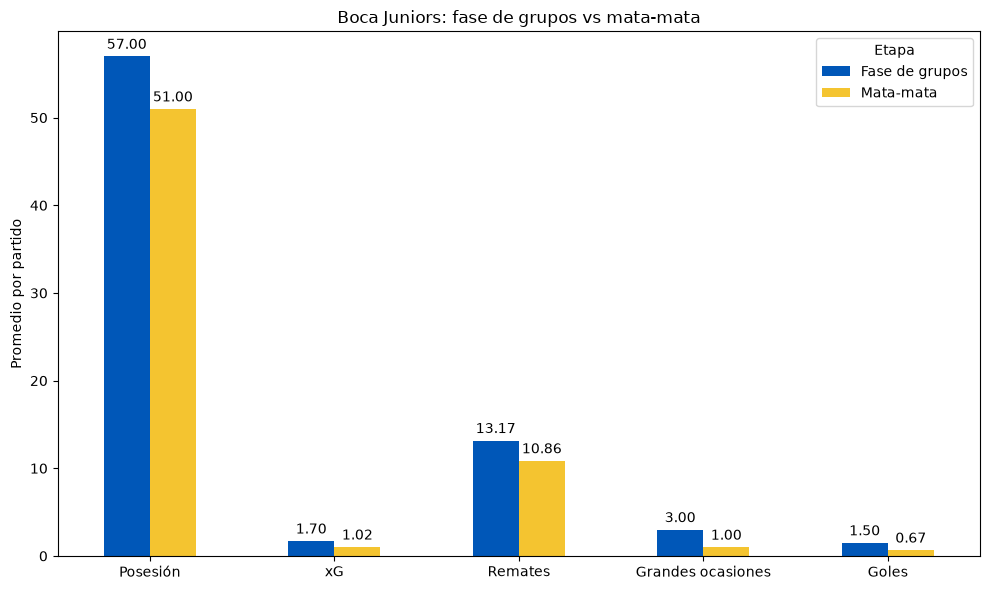

In [349]:
metricas_grafico_1 = [
    'posesion',
    'xG',
    'remates',
    'grandes_ocasiones',
    'goles'
]

grafico_1 = comparacion_etapas_boca.loc[
    metricas_grafico_1
].copy()

grafico_1.index = [
    'Posesión',
    'xG',
    'Remates',
    'Grandes ocasiones',
    'Goles'
]

colores = [azul_fuerte, amarillo]

ax = grafico_1.plot(
    kind='bar',
    figsize=(10, 6),
    color=colores
)

ax.set_title('Boca Juniors: fase de grupos vs mata-mata')
ax.set_xlabel('')
ax.set_ylabel('Promedio por partido')
ax.legend(title='Etapa')

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.2f', padding=3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 11.2 Boca: local vs visitante en mata-mata previo a la final

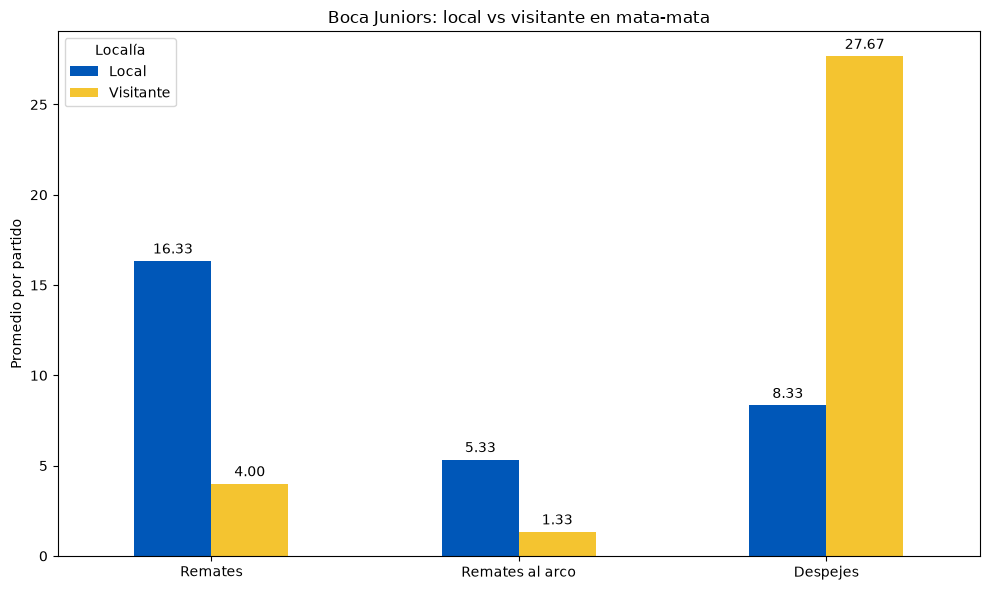

In [350]:
metricas_grafico_2 = [
    'remates_boca',
    'remates_arco_boca',
    'despejes_boca'
]

grafico_2 = modelo_local_visitante[
    metricas_grafico_2
].T.copy()

grafico_2.index = [
    'Remates',
    'Remates al arco',
    'Despejes'
]

colores = [azul_fuerte, amarillo]

ax = grafico_2.plot(
    kind='bar',
    figsize=(10, 6),
    color=colores
)

ax.set_title('Boca Juniors: local vs visitante en mata-mata')
ax.set_xlabel('')
ax.set_ylabel('Promedio por partido')
ax.legend(title='Localía')

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt='%.2f',
        padding=3
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 11.3 Boca: xG local vs visitante en mata-mata previo a la final

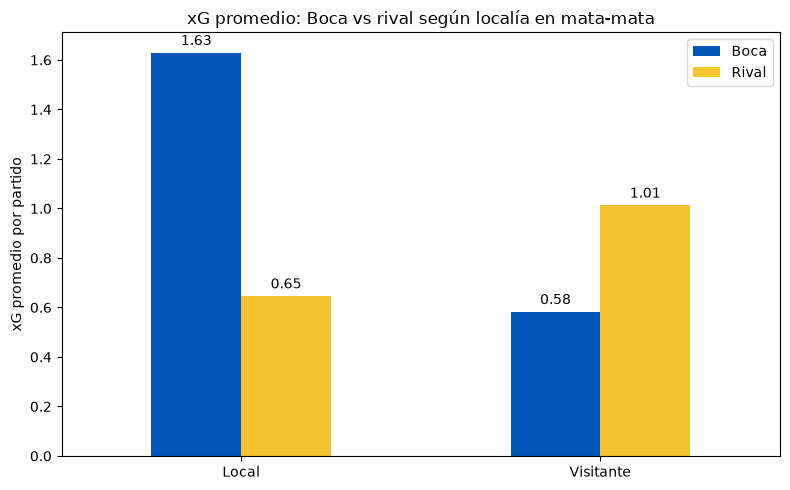

In [353]:
grafico_3 = modelo_local_visitante[
    ['xG_boca', 'xG_rival']
].copy()

ax = grafico_3.plot(
    kind='bar',
    figsize=(8, 5),
    color=[azul_fuerte, amarillo]
)

ax.set_title('xG promedio: Boca vs rival según localía en mata-mata')
ax.set_xlabel('')
ax.set_ylabel('xG promedio por partido')
ax.legend([
    'Boca',
    'Rival'
])

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt='%.2f',
        padding=3
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 11.4 Sergio Romero: efectividad en tandas de penales

In [346]:
grafico_romero = pd.DataFrame({
    'Arquero / período': [
        'Romero\nLibertadores 2023',
        'Romero\nResto de su carrera',
        'Córdoba\nLibertadores 2000/01'
    ],
    'Porcentaje atajado': [
        comparacion_tandas_romero.loc[
            'Libertadores 2023',
            'pct_atajados'
        ],
        comparacion_tandas_romero.loc[
            'Resto de las tandas de su carrera',
            'pct_atajados'
        ],
        resumen_cordoba.loc[
            'Óscar Córdoba - Libertadores 2000/2001',
            'pct_atajados'
        ]
    ]
})

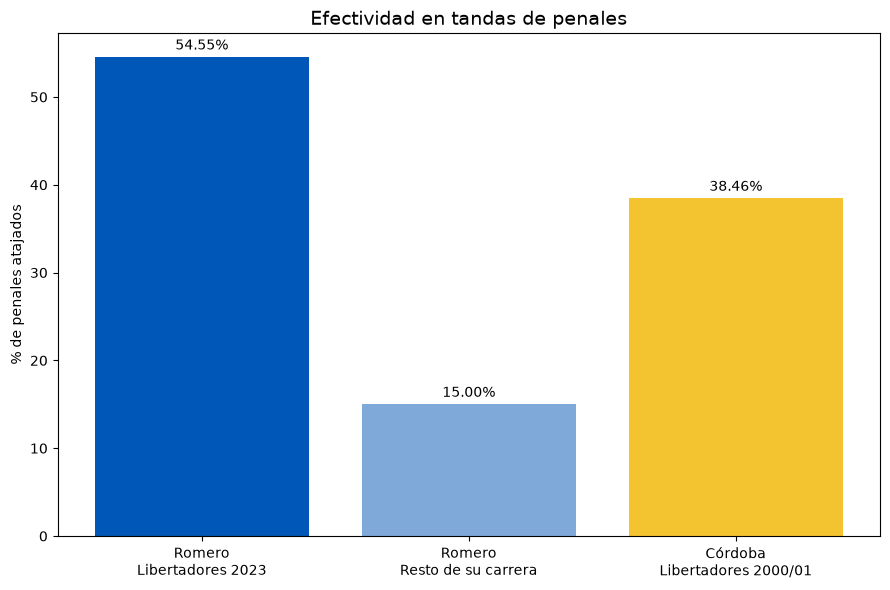

In [347]:
colores = [
    '#0057B8',  # Romero Libertadores 2023
    '#7FA9D8',  # Romero resto de su carrera
    '#F4C430'   # Córdoba 2000/01
]

fig, ax = plt.subplots(figsize=(9, 6))

barras = ax.bar(
    grafico_romero['Arquero / período'],
    grafico_romero['Porcentaje atajado'],
    color=colores
)

ax.set_title(
    'Efectividad en tandas de penales',
    fontsize=14
)

ax.set_ylabel('% de penales atajados')
ax.set_xlabel('')

ax.bar_label(
    barras,
    fmt='%.2f%%',
    padding=3
)

plt.xticks(
    rotation=0,
    ha='center'
)

plt.tight_layout()
plt.show()

### 11.5 xG acumulado por serie: Boca vs rival previo a la final

In [354]:
grafico_5 = comparacion_series[
    [
        'serie',
        'xG_boca',
        'xG_rival'
    ]
].copy()

grafico_5 = grafico_5.set_index('serie')

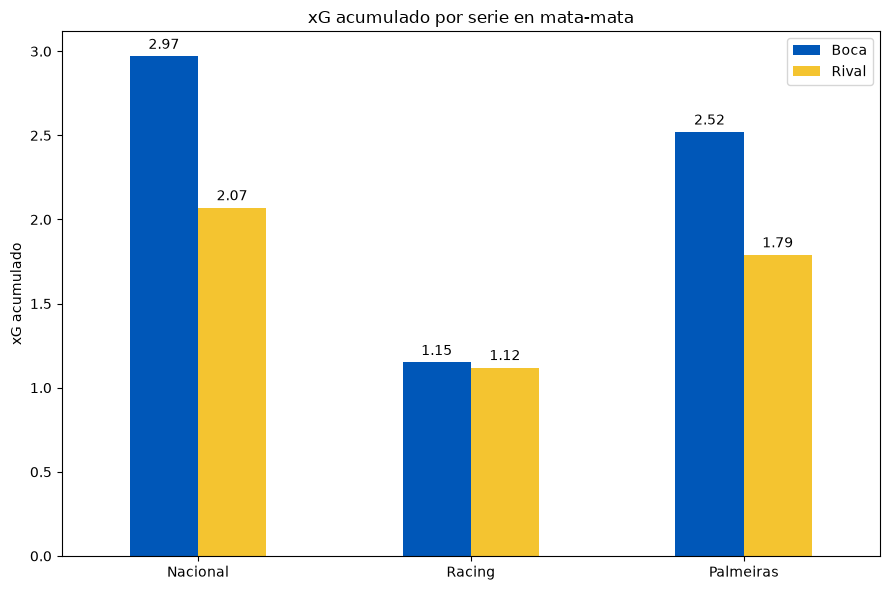

In [355]:
ax = grafico_5.plot(
    kind='bar',
    figsize=(9, 6),
    color=[azul_fuerte, amarillo]
)

ax.set_title('xG acumulado por serie en mata-mata')
ax.set_xlabel('')
ax.set_ylabel('xG acumulado')
ax.legend([
    'Boca',
    'Rival'
])

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt='%.2f',
        padding=3
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 11.6 Final: Boca vs Fluminense en los 90 minutos

In [356]:
grafico_final = final_90.loc[
    [
        'Remates',
        'Remates al arco',
        'Grandes ocasiones',
        'Despejes',
        'Atajadas'
    ]
].copy()

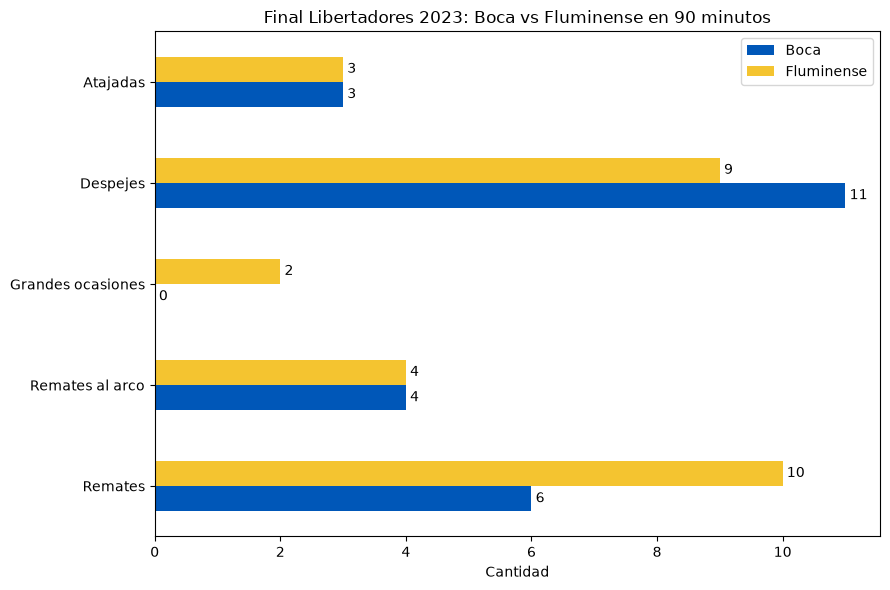

In [357]:
ax = grafico_final.plot(
    kind='barh',
    figsize=(9, 6),
    color=[azul_fuerte, amarillo]
)

ax.set_title('Final Libertadores 2023: Boca vs Fluminense en 90 minutos')
ax.set_xlabel('Cantidad')
ax.set_ylabel('')
ax.legend([
    'Boca',
    'Fluminense'
])

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt='%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

### 11.7 Cambio de protagonistas: fase de grupos vs mata-mata

In [368]:
jugadores_grafico_7 = [
    'Alan Varela',
    'Ezequiel Fernández',
    'Cristian Medina',
    'Pol Fernández',
    'Valentín Barco',
    'Luis Advíncula',
    'Miguel Merentiel',
    'Edinson Cavani',
    'Marcos Rojo',
    'Nicolás Figal'
]

grafico_7 = titularidades_comparacion.loc[
    jugadores_grafico_7,
    ['% grupos', '% mata-mata']
].copy()

grafico_7 = grafico_7.sort_values(
    '% mata-mata'
)

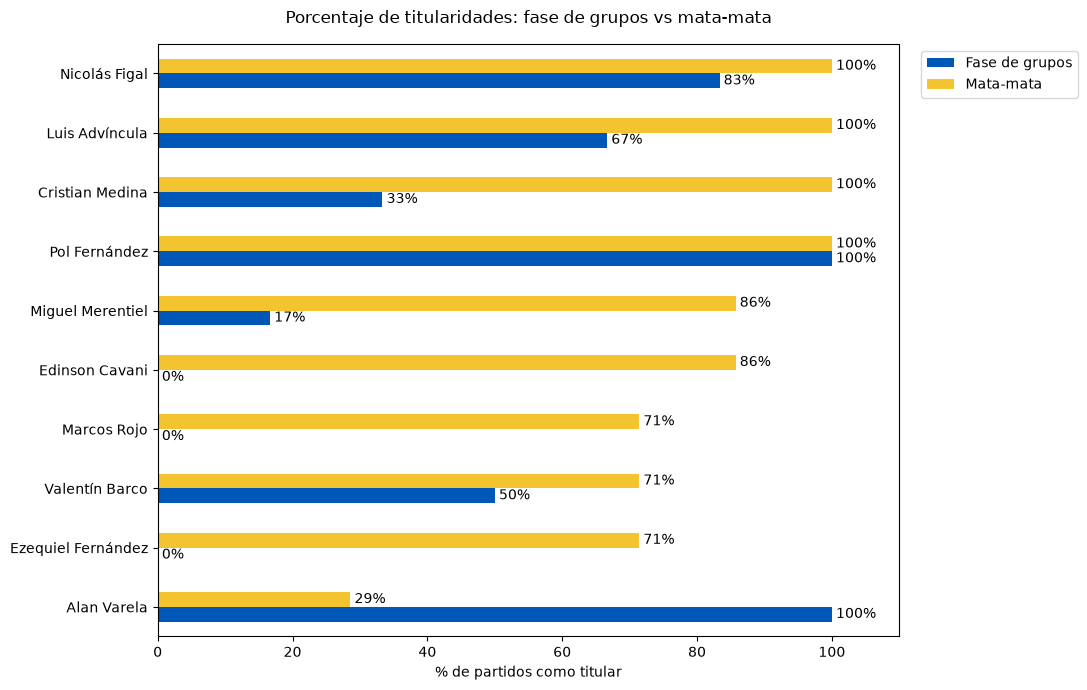

In [372]:
ax = grafico_7.plot(
    kind='barh',
    figsize=(11, 7),
    color=[azul_fuerte, amarillo]
)

ax.set_title(
    'Porcentaje de titularidades: fase de grupos vs mata-mata',
    pad=15
)

ax.set_xlabel('% de partidos como titular')
ax.set_ylabel('')

ax.set_xlim(0, 110)

ax.legend(
    ['Fase de grupos', 'Mata-mata'],
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt='%.0f%%',
        padding=3
    )

plt.tight_layout()
plt.show()

**Lectura:** el mata-mata no solamente modificó la estructura táctica de Boca, sino también sus principales protagonistas. La salida de Alan Varela coincidió con la consolidación de Equi Fernández, mientras Medina, Merentiel, Rojo y Barco aumentaron su presencia. Cavani se incorporó directamente para las eliminatorias, mientras jugadores como Pol Fernández, Advíncula y Figal funcionaron como piezas de continuidad entre ambas etapas.